# Supplementary report figures

Additional thesis figures that are not part of the main curated set in
`REPORT_final_FINAL.ipynb`. Plot helpers live under `report_final/`.

- **Output:** `local/plots/final/aide/` — one PDF per figure, plus CSV tables.
- **Styling:** same report typography as the main notebook (`report_final.style`).
  Category x ticks stay horizontal; Shampoo optimizers use two-line labels
  (`Pure\nShampoo`, `Grafted\nShampoo`). Only the Vaidya scorecard in the main
  notebook rotates optimizer ticks.
- **Eval errors:** hardcoded in `report_final.eval_errors` from checkpoint
  evaluation runs; extend that file when new experiments are measured.
- **Training losses:** loss timelines only (no PF / Gaussian analysis).
- **Two rooms alive proportion:** `plot_dual_room_metric_by_optimizer` (figure 06
  style; muted = train_other), with room/rep boundaries matching the loss figure.
- **Single room:** one `compute_all_optimizer_results` load (main-report pipeline).
- **Ratemap peaks:** Gaussian `signal_max` at the final capture from `results.meta`.
- **Activity ranks:** final Gaussian RF fits for the most-active and 7th-most-active cells.
- **PF revives:** mean revives per PF normalized by distinct place-field count.
- **PF length / drift:** two-panel bar chart (length + x/y/mean drift) with significance.
- **PF RAT / peak amplitude / spontaneous:** two-panel bar chart (RAT + peak
  amplitude, then spontaneous PF formations) with significance.
- **PF shift vs Vaidya (cm rescaling only):** same Fig 2d overlay as the main
  report, but Vaidya cm/PDF are mapped to the 100 cm room axis with no other
  normalization.

In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Setup

In [34]:
import sys
from pathlib import Path

from IPython.display import display

for _path in (Path.cwd(), *Path.cwd().parents):
    if (_path / "pyproject.toml").is_file():
        PROJECT_ROOT = _path
        NOTEBOOK_DIR = Path.cwd()
        for p in (str(_path / "src"), str(_path / "local"), str(_path)):
            if p not in sys.path:
                sys.path.insert(0, p)
        break
else:
    raise RuntimeError("Could not find project root (pyproject.toml)")

from report_final import eval_error_plots as eep
from report_final import single_room_pf_plots as srpf
from report_final import single_room_ratemap_plots as srmp
from report_final import training_loss_plots as tlp
from report_final import two_rooms_pf_plots as trpf
from report_final.notebook_cache import report_final_cache_dir
from report_final.style import apply_report_style, finalize, report_font, save_report_table

apply_report_style()

PLOT_DIR = NOTEBOOK_DIR / "plots/final/aide"
CACHE_DIR = report_final_cache_dir(PROJECT_ROOT)
USE_CACHE = True
FORCE_RECOMPUTE = False
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SINGLE_ROOM_CONFIG = PROJECT_ROOT / "input_configs/single_room.json"
TWO_ROOMS_CONFIG = PROJECT_ROOT / "input_configs/two_rooms.json"
RESULTS_PARENT_OVERRIDE = None

# Shared with REPORT_final_FINAL.ipynb / single_room_multi_opt.ipynb
DEAD_THRESHOLD_FRAC = 0.4
R2_THRESHOLD = 0.8
NUM_GAUSS_THRESHOLD = 1.5
PF_TRACKING_METHOD = "revive_mean_displacement"
CONSTANT_L2_SIMILARITY = 10.0
MAX_FACTOR_PCT = 0.95
PEAK_ANALYSIS_TECHNIQUE = "local"
ZOOM_IN_WIDTH = 0.25

SHOW_SIGNIFICANCE = True
SHOW_INSIGNIFICANCE = True

print(f"Project root: {PROJECT_ROOT}")
print(f"Plot output:  {PLOT_DIR}")
print(f"Cache dir:    {CACHE_DIR} (USE_CACHE={USE_CACHE})")
print(f"Experiments:  {list(eep.list_eval_error_experiments())}")
print(f"Fonts:        {report_font()}")


Project root: /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn
Plot output:  /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide
Cache dir:    /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/_cache (USE_CACHE=True)
Experiments:  ['single_room', 'single_room_plateau', 'two_rooms']
Fonts:        {'tick': 13, 'axis_label': 15, 'panel_title': 14, 'row_title': 15, 'suptitle': 18, 'legend': 12, 'legend_title': 13, 'annotation': 12, 'sig': 14, 'colorbar_label': 14, 'colorbar_tick': 12}


## Checkpoint eval error by optimizer

One bar chart per experiment. Values are from held-out trajectory evaluation
on the best checkpoint per optimizer (`local/eval_single_room_ckpt_eval_error.py`).

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/eval_error_single_room.csv


,experiment,optimizer,optimizer_label,eval_error
0,single_room,sgd,SGD,0.536354
1,single_room,adagrad,AdaGrad,0.322921
2,single_room,adam,Adam,0.310226
3,single_room,pure_shampoo,Pure Shampoo,0.170075
4,single_room,grafted_shampoo,Grafted Shampoo,0.138351


Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/eval_error_single_room.pdf


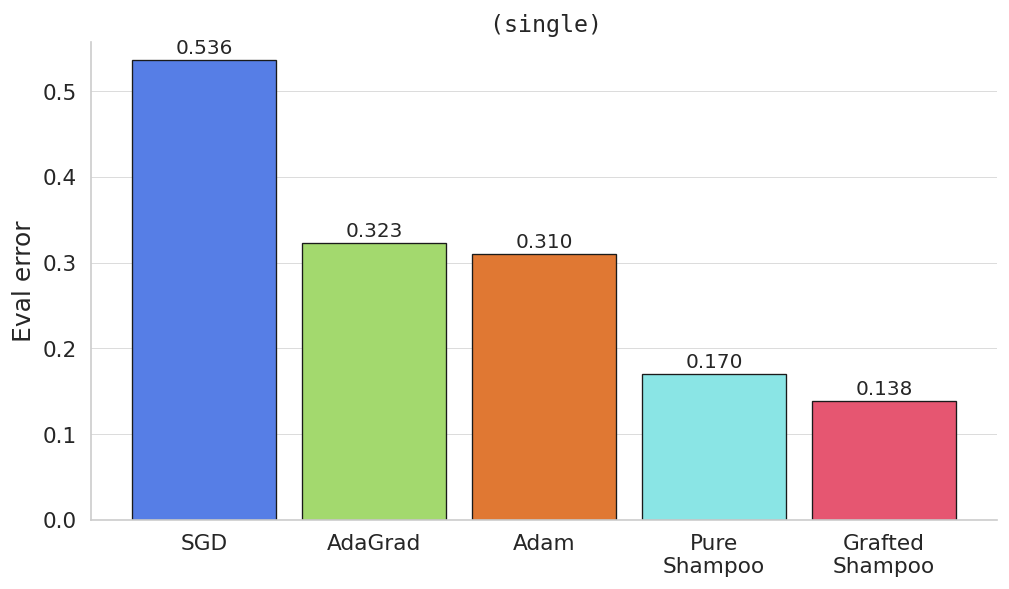

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/eval_error_single_room_plateau.csv


,experiment,optimizer,optimizer_label,eval_error
0,single_room_plateau,sgd,SGD,0.537793
1,single_room_plateau,adagrad,AdaGrad,0.286435
2,single_room_plateau,adam,Adam,0.294879
3,single_room_plateau,pure_shampoo,Pure Shampoo,0.181952
4,single_room_plateau,grafted_shampoo,Grafted Shampoo,0.139110


Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/eval_error_single_room_plateau.pdf


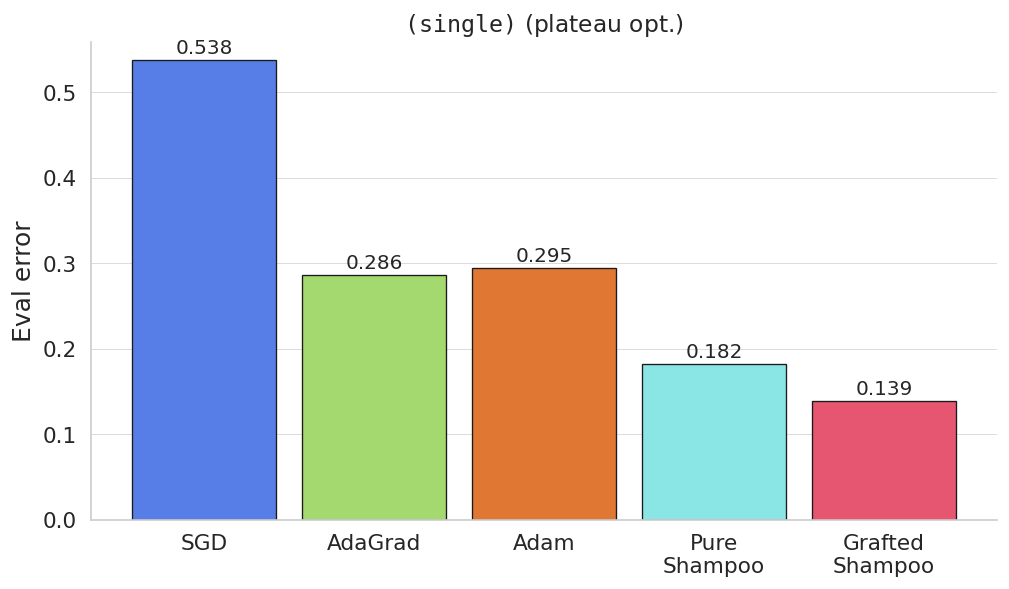

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/eval_error_two_rooms.csv


,experiment,optimizer,optimizer_label,eval_error
0,two_rooms,sgd,SGD,0.371588
1,two_rooms,adagrad,AdaGrad,0.313995
2,two_rooms,adam,Adam,0.324671
3,two_rooms,pure_shampoo,Pure Shampoo,0.204561
4,two_rooms,grafted_shampoo,Grafted Shampoo,0.147806


Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/eval_error_two_rooms.pdf


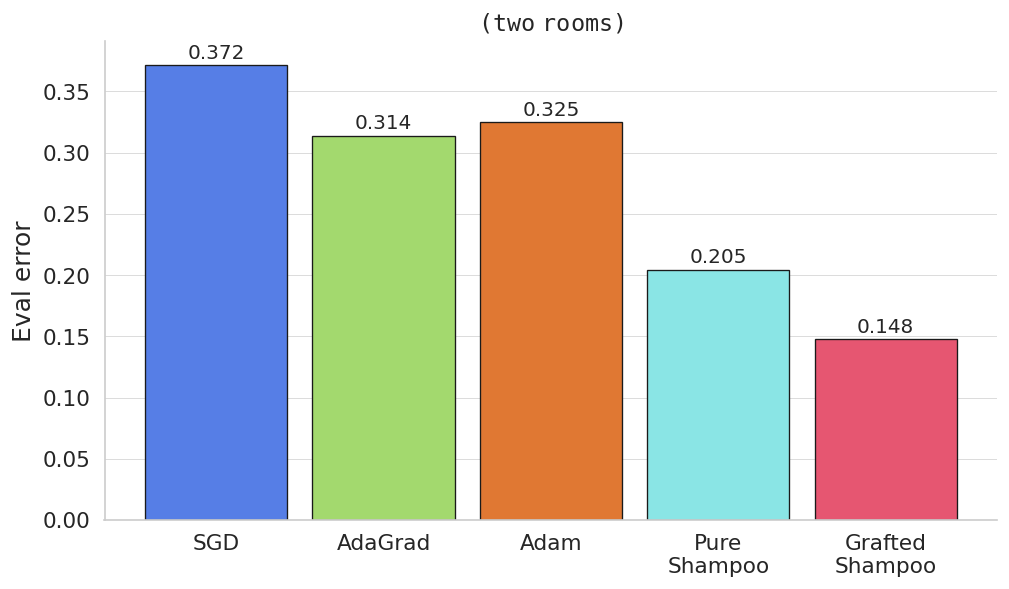

In [35]:
for experiment in eep.list_eval_error_experiments():
    table = eep.eval_error_table(experiment)
    save_report_table(table, PLOT_DIR, f"eval_error_{experiment}")
    display(table)

    fig = eep.plot_eval_error_by_optimizer(experiment)
    finalize(fig, PLOT_DIR, f"eval_error_{experiment}", restyle=False)

## Two rooms — training loss by optimizer

Loss timelines only — no place-field analysis. Same plot helper as
`two_rooms_multiopt.ipynb`, saved through `finalize()` for report typography.

In [36]:
tr, tr_segment_duration_s = tlp.load_two_rooms_training_loss_results(
    project_root=PROJECT_ROOT,
    config_path=TWO_ROOMS_CONFIG,
    results_parent_override=RESULTS_PARENT_OVERRIDE,
)
print("Two-room loss timelines ready for:", list(tr.training))

Loading two-rooms training loss:   0%|          | 0/5 [00:00<?, ?it/s]

Two-room loss timelines ready for: ['sgd', 'adagrad', 'adam', 'pure_shampoo', 'grafted_shampoo']


Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/two_rooms_training_loss.csv
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/two_rooms_training_loss.pdf


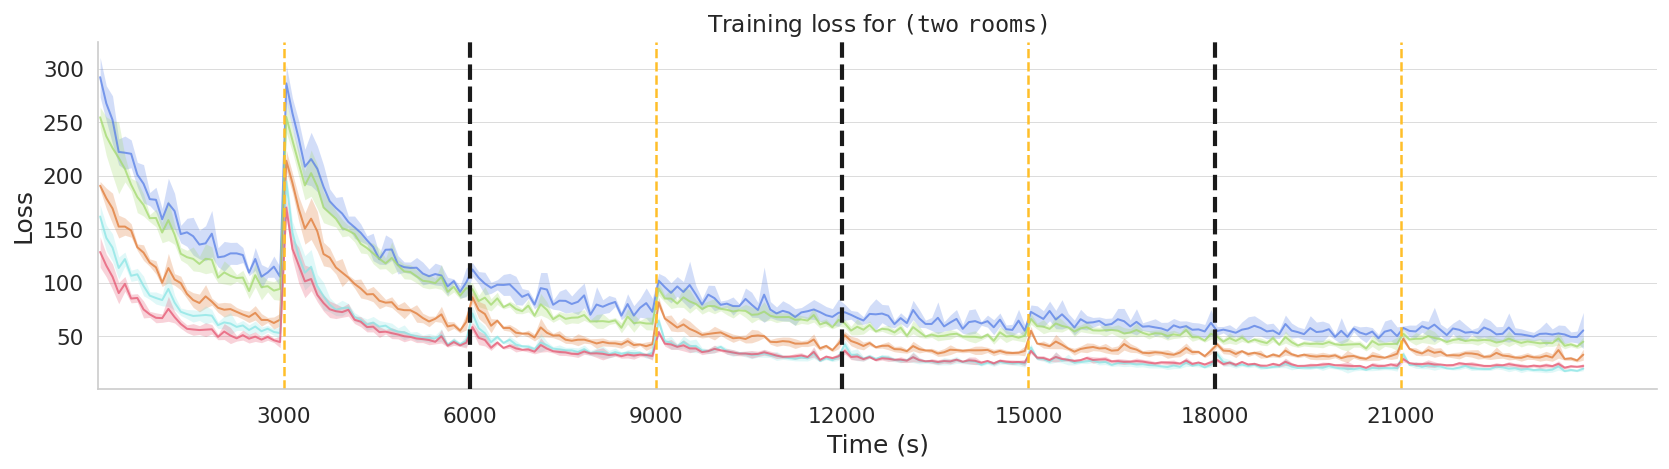

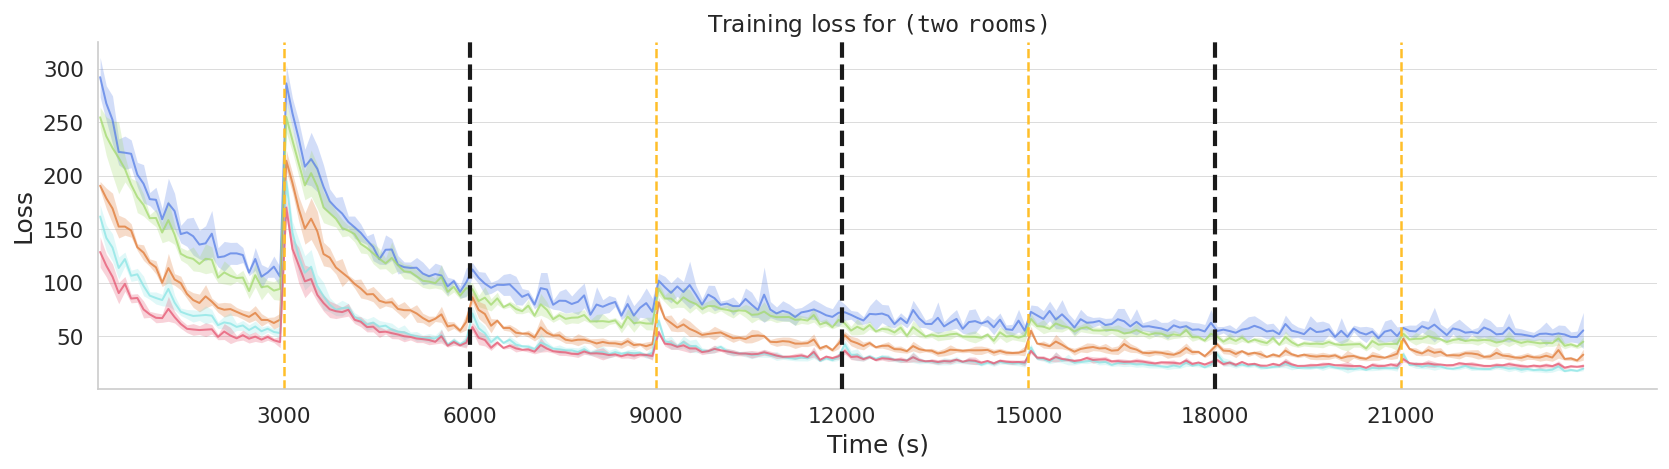

In [37]:
loss_table = tlp.two_rooms_training_loss_table(tr)
save_report_table(loss_table, PLOT_DIR, "two_rooms_training_loss")

TRACE_ALPHA = 0.75
LOSS_SUBSAMPLE_WIN_SIZE = 5

fig = tlp.plot_two_rooms_training_loss(
    tr,
    segment_duration_s=tr_segment_duration_s,
    trace_alpha=TRACE_ALPHA,
    subsample_win_size=LOSS_SUBSAMPLE_WIN_SIZE,
    title=r"Training loss for $\mathtt{(two\ rooms)}$",
)
finalize(fig, PLOT_DIR, "two_rooms_training_loss")

## Two rooms — alive proportion by optimizer

Same helper as `REPORT_final_FINAL.ipynb` figure 06
(`plot_dual_room_metric_by_optimizer`, muted segments = train_other),
with `y` in `[0, 0.5]` and room/rep boundary lines matching the two-room
loss figure above (`show_traj_boundaries=False`).

Loaded two-room results from cache: /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/_cache/two_rooms.pkl.gz
Two-room PF results ready for: ['sgd', 'adagrad', 'adam', 'pure_shampoo', 'grafted_shampoo']
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/two_rooms_alive_proportion.csv
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/two_rooms_alive_proportion.pdf


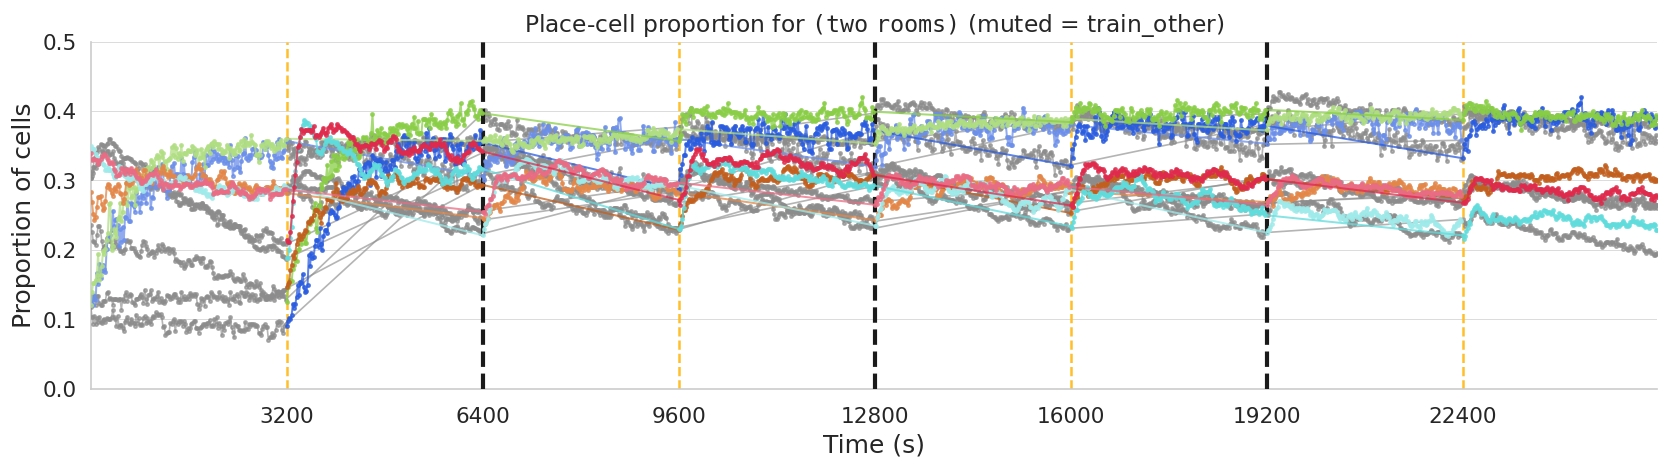

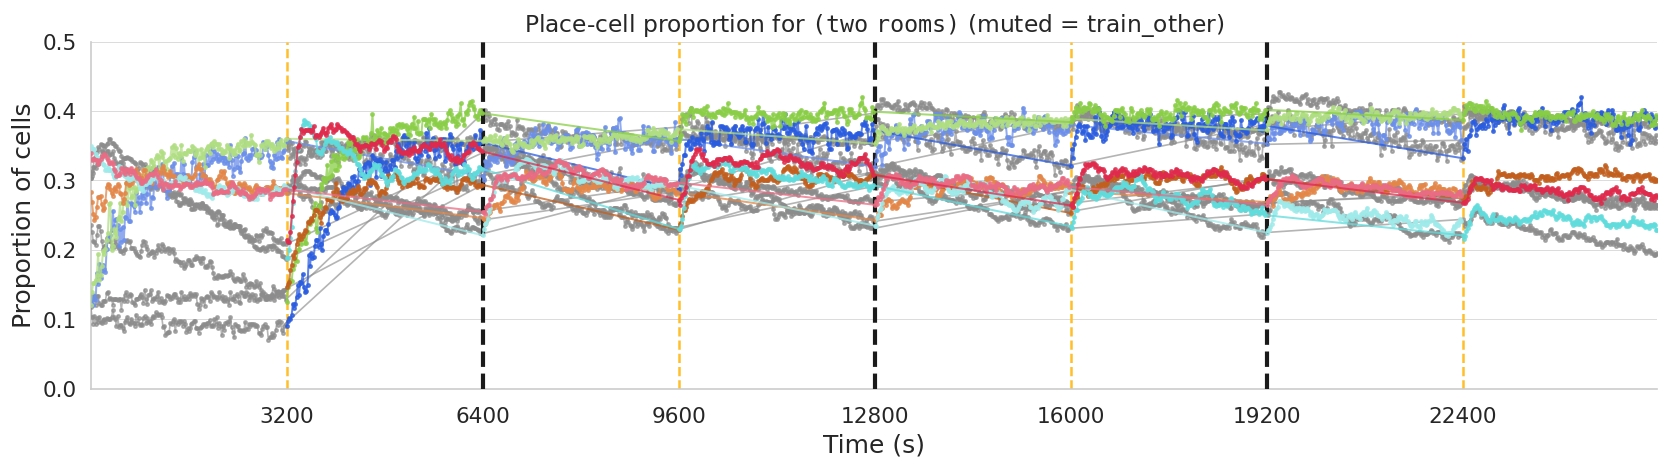

In [38]:
tr_pf = trpf.load_two_rooms_optimizer_results(
    project_root=PROJECT_ROOT,
    config_path=TWO_ROOMS_CONFIG,
    results_parent_override=RESULTS_PARENT_OVERRIDE,
    dead_threshold_frac=DEAD_THRESHOLD_FRAC,
    r2_threshold=R2_THRESHOLD,
    num_gauss_threshold=NUM_GAUSS_THRESHOLD,
    pf_tracking_method=PF_TRACKING_METHOD,
    zoom_bin_width=ZOOM_IN_WIDTH,
    constant_l2_similarity=CONSTANT_L2_SIMILARITY,
    max_factor_pct=MAX_FACTOR_PCT,
    peak_analysis_technique=PEAK_ANALYSIS_TECHNIQUE,
    cache_dir=CACHE_DIR,
    use_cache=USE_CACHE,
    force_recompute=FORCE_RECOMPUTE,
)
tr_pf_segment_duration_s = next(iter(tr_pf.contexts.values())).segment_duration_s
print("Two-room PF results ready for:", list(tr_pf.pf))

alive_table = trpf.two_rooms_alive_proportion_table(tr_pf)
save_report_table(alive_table, PLOT_DIR, "two_rooms_alive_proportion")

fig = trpf.plot_two_rooms_alive_proportion(
    tr_pf,
    segment_duration_s=tr_pf_segment_duration_s,
    trace_alpha=TRACE_ALPHA,
    y_lims=(0.0, 0.5),
    show_traj_boundaries=False,
    show_legend=False,
    title=(
        r"Place-cell proportion for $\mathtt{(two\ rooms)}$ "
        f"(muted = train_other)"
    ),
)
finalize(fig, PLOT_DIR, "two_rooms_alive_proportion")

## Two rooms — consolidation scorecard (Vaidya §5–§9)

Subset of the main-report scorecard: across-day consolidation statistics (§5–§8)
plus reappearance-shift gradedness (§9). Within-session BTSP timing rows from §10
are omitted.

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/table_vaidya_scorecard_consolidation.csv
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/vaidya_scorecard_consolidation.pdf


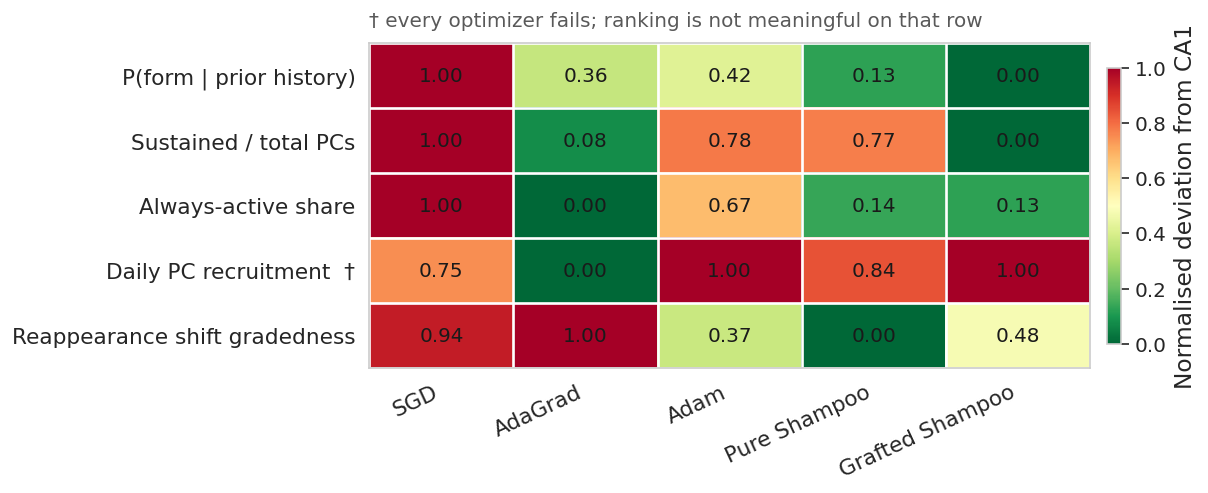

Raw absolute deviations (quote these for the † row):


optimizer,adagrad,adam,grafted_shampoo,pure_shampoo,sgd
statistic,,,,,
formation_probability,0.241,0.249,0.194,0.211,0.324
sustained_fraction,0.039,0.192,0.021,0.190,0.240
always_active,0.455,0.599,0.482,0.484,0.670
new_pc_fraction,0.488,0.529,0.529,0.523,0.519
shift_gradedness,0.149,0.076,0.088,0.033,0.142


Normalised deviation (0 = closest to CA1 among optimizers, 1 = furthest):


optimizer,adagrad,adam,grafted_shampoo,pure_shampoo,sgd
statistic,,,,,
formation_probability,0.362,0.42,0.000,0.128,1.000
sustained_fraction,0.082,0.78,0.000,0.772,1.000
always_active,0.000,0.67,0.127,0.137,1.000
new_pc_fraction,0.000,1.00,0.998,0.843,0.746
shift_gradedness,1.000,0.37,0.478,0.000,0.939


In [39]:
from report_final import bioplausibility as bio

scorecard_full = bio.build_scorecard(tr_pf)
scorecard = bio.subset_scorecard(
    scorecard_full, bio.CONSOLIDATION_SPATIAL_SCORECARD_STATISTICS
)
save_report_table(scorecard, PLOT_DIR, "table_vaidya_scorecard_consolidation")

fig = bio.plot_scorecard(scorecard, figsize=(10.5, 4.2))
finalize(fig, PLOT_DIR, "vaidya_scorecard_consolidation", restyle=False)

print("Raw absolute deviations (quote these for the † row):")
display(
    scorecard.pivot(index="statistic", columns="optimizer", values="abs_deviation")
    .reindex(index=bio.CONSOLIDATION_SPATIAL_SCORECARD_STATISTICS)
    .round(3)
)
print("Normalised deviation (0 = closest to CA1 among optimizers, 1 = furthest):")
display(
    scorecard.pivot(index="statistic", columns="optimizer", values="normalized_deviation")
    .reindex(index=bio.CONSOLIDATION_SPATIAL_SCORECARD_STATISTICS)
    .round(3)
)

## Two rooms — PF shift vs Vaidya (cm rescaling only)

Same bin grid as `plot_cell_displacement_by_optimizer_two_rooms` (−8 to +8 cm,
`zoom_bin_width`). Model pools `displacement_x` and `displacement_y`. Vaidya
Fig 2d is mapped from 183.6 cm → 100 cm with the matching PDF rescaling.

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/vaidya_pf_shift_spatial_only.pdf


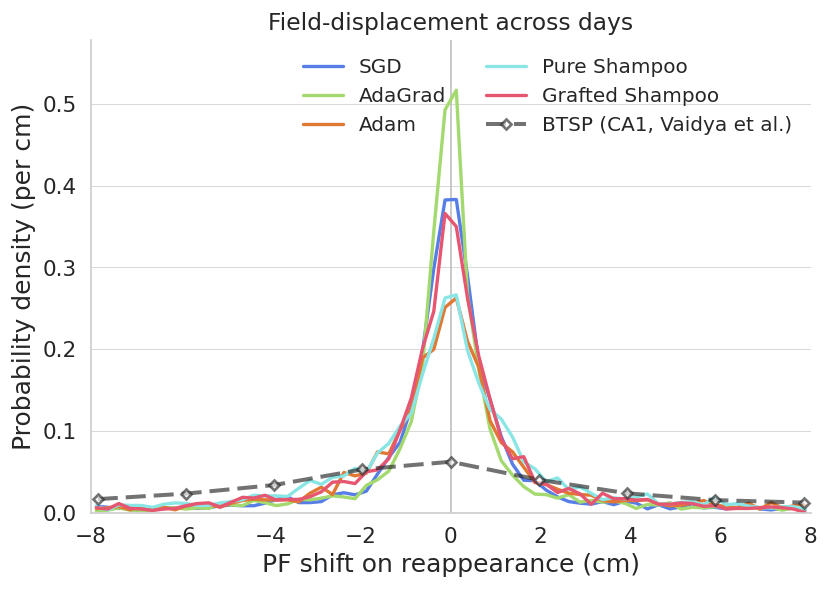

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/table_vaidya_pf_shift_bands_spatial_only.csv


,source,adagrad,adam,grafted_shampoo,pure_shampoo,sgd,vaidya
band_lo,band_hi,,,,,,
0.0,2.0,0.638332,0.518745,0.606450,0.537407,0.614540,0.303702
2.0,10.0,0.124604,0.185819,0.184444,0.232863,0.129971,0.287787
10.0,50.0,0.134284,0.172168,0.133853,0.143557,0.146198,0.408511


In [40]:
from report_final.bioplausibility import (
    model_shift_bands_spatial_only,
    plot_pf_shift_vs_vaidya_spatial_only,
)

fig = plot_pf_shift_vs_vaidya_spatial_only(
    tr_pf,
    bin_width=ZOOM_IN_WIDTH,
    bin_range=(-8.0, 8.0),
	figsize=(7.0, 5.0),
	show_second_ax = False
)
finalize(fig, PLOT_DIR, "vaidya_pf_shift_spatial_only", restyle=False)

bands = model_shift_bands_spatial_only(tr_pf)
save_report_table(bands, PLOT_DIR, "table_vaidya_pf_shift_bands_spatial_only")
display(bands.pivot(index=["band_lo", "band_hi"], columns="source", values="fraction"))

## Single room — shared results

One pass through `build_optimizer_contexts` → `compute_all_optimizer_results`,
as in `REPORT_final_FINAL.ipynb`, reusing its `local/_cache/single_room.pkl.gz`
when present. All single-room panels below read from
`sr_results.meta` / `sr_results.pf`.


In [41]:
sr_results = srpf.load_single_room_optimizer_results(
    project_root=PROJECT_ROOT,
    config_path=SINGLE_ROOM_CONFIG,
    results_parent_override=RESULTS_PARENT_OVERRIDE,
    dead_threshold_frac=DEAD_THRESHOLD_FRAC,
    r2_threshold=R2_THRESHOLD,
    num_gauss_threshold=NUM_GAUSS_THRESHOLD,
    pf_tracking_method=PF_TRACKING_METHOD,
    zoom_bin_width=ZOOM_IN_WIDTH,
    constant_l2_similarity=CONSTANT_L2_SIMILARITY,
    max_factor_pct=MAX_FACTOR_PCT,
    peak_analysis_technique=PEAK_ANALYSIS_TECHNIQUE,
    cache_dir=CACHE_DIR,
    use_cache=USE_CACHE,
    force_recompute=FORCE_RECOMPUTE,
)
print("Single-room results ready for:", list(sr_results.meta))


Loaded single-room results from cache: /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/_cache/single_room.pkl.gz
Single-room results ready for: ['sgd', 'adagrad', 'adam', 'pure_shampoo', 'grafted_shampoo']


## PF metric bars by optimizer (full panels)

Full stacked bar chart from `plot_pf_metric_bars_by_optimizer` (single room)
and `plot_pf_metric_bars_by_optimizer_two_rooms` (two rooms, aggregated across
rooms): PF length, drift, RAT, peak amplitude, and spontaneous PF formations.

[PF length (s)] 9 significant pair(s) (Welch t-test, Holm corrected):
  SGD vs AdaGrad: raw p=7.40e-46, Holm p=5.18e-45 (***)
  SGD vs Adam: raw p=3.45e-99, Holm p=3.45e-98 (***)
  SGD vs Pure Shampoo: raw p=4.05e-89, Holm p=3.64e-88 (***)
  SGD vs Grafted Shampoo: raw p=3.16e-73, Holm p=2.52e-72 (***)
  AdaGrad vs Adam: raw p=2.00e-06, Holm p=8.02e-06 (***)
  AdaGrad vs Pure Shampoo: raw p=3.64e-12, Holm p=1.82e-11 (***)
  AdaGrad vs Grafted Shampoo: raw p=3.88e-15, Holm p=2.33e-14 (***)
  Adam vs Pure Shampoo: raw p=3.89e-03, Holm p=7.79e-03 (**)
  Adam vs Grafted Shampoo: raw p=9.56e-06, Holm p=2.87e-05 (***)
[Formation onset (s)] 8 significant pair(s) (Welch t-test, Holm corrected):
  SGD vs Adam: raw p=2.52e-09, Holm p=2.02e-08 (***)
  SGD vs Pure Shampoo: raw p=1.64e-05, Holm p=9.63e-05 (***)
  SGD vs Grafted Shampoo: raw p=1.24e-03, Holm p=4.96e-03 (**)
  AdaGrad vs Adam: raw p=6.03e-09, Holm p=4.22e-08 (***)
  AdaGrad vs Pure Shampoo: raw p=1.60e-05, Holm p=9.63e-05 (***)
  Ada

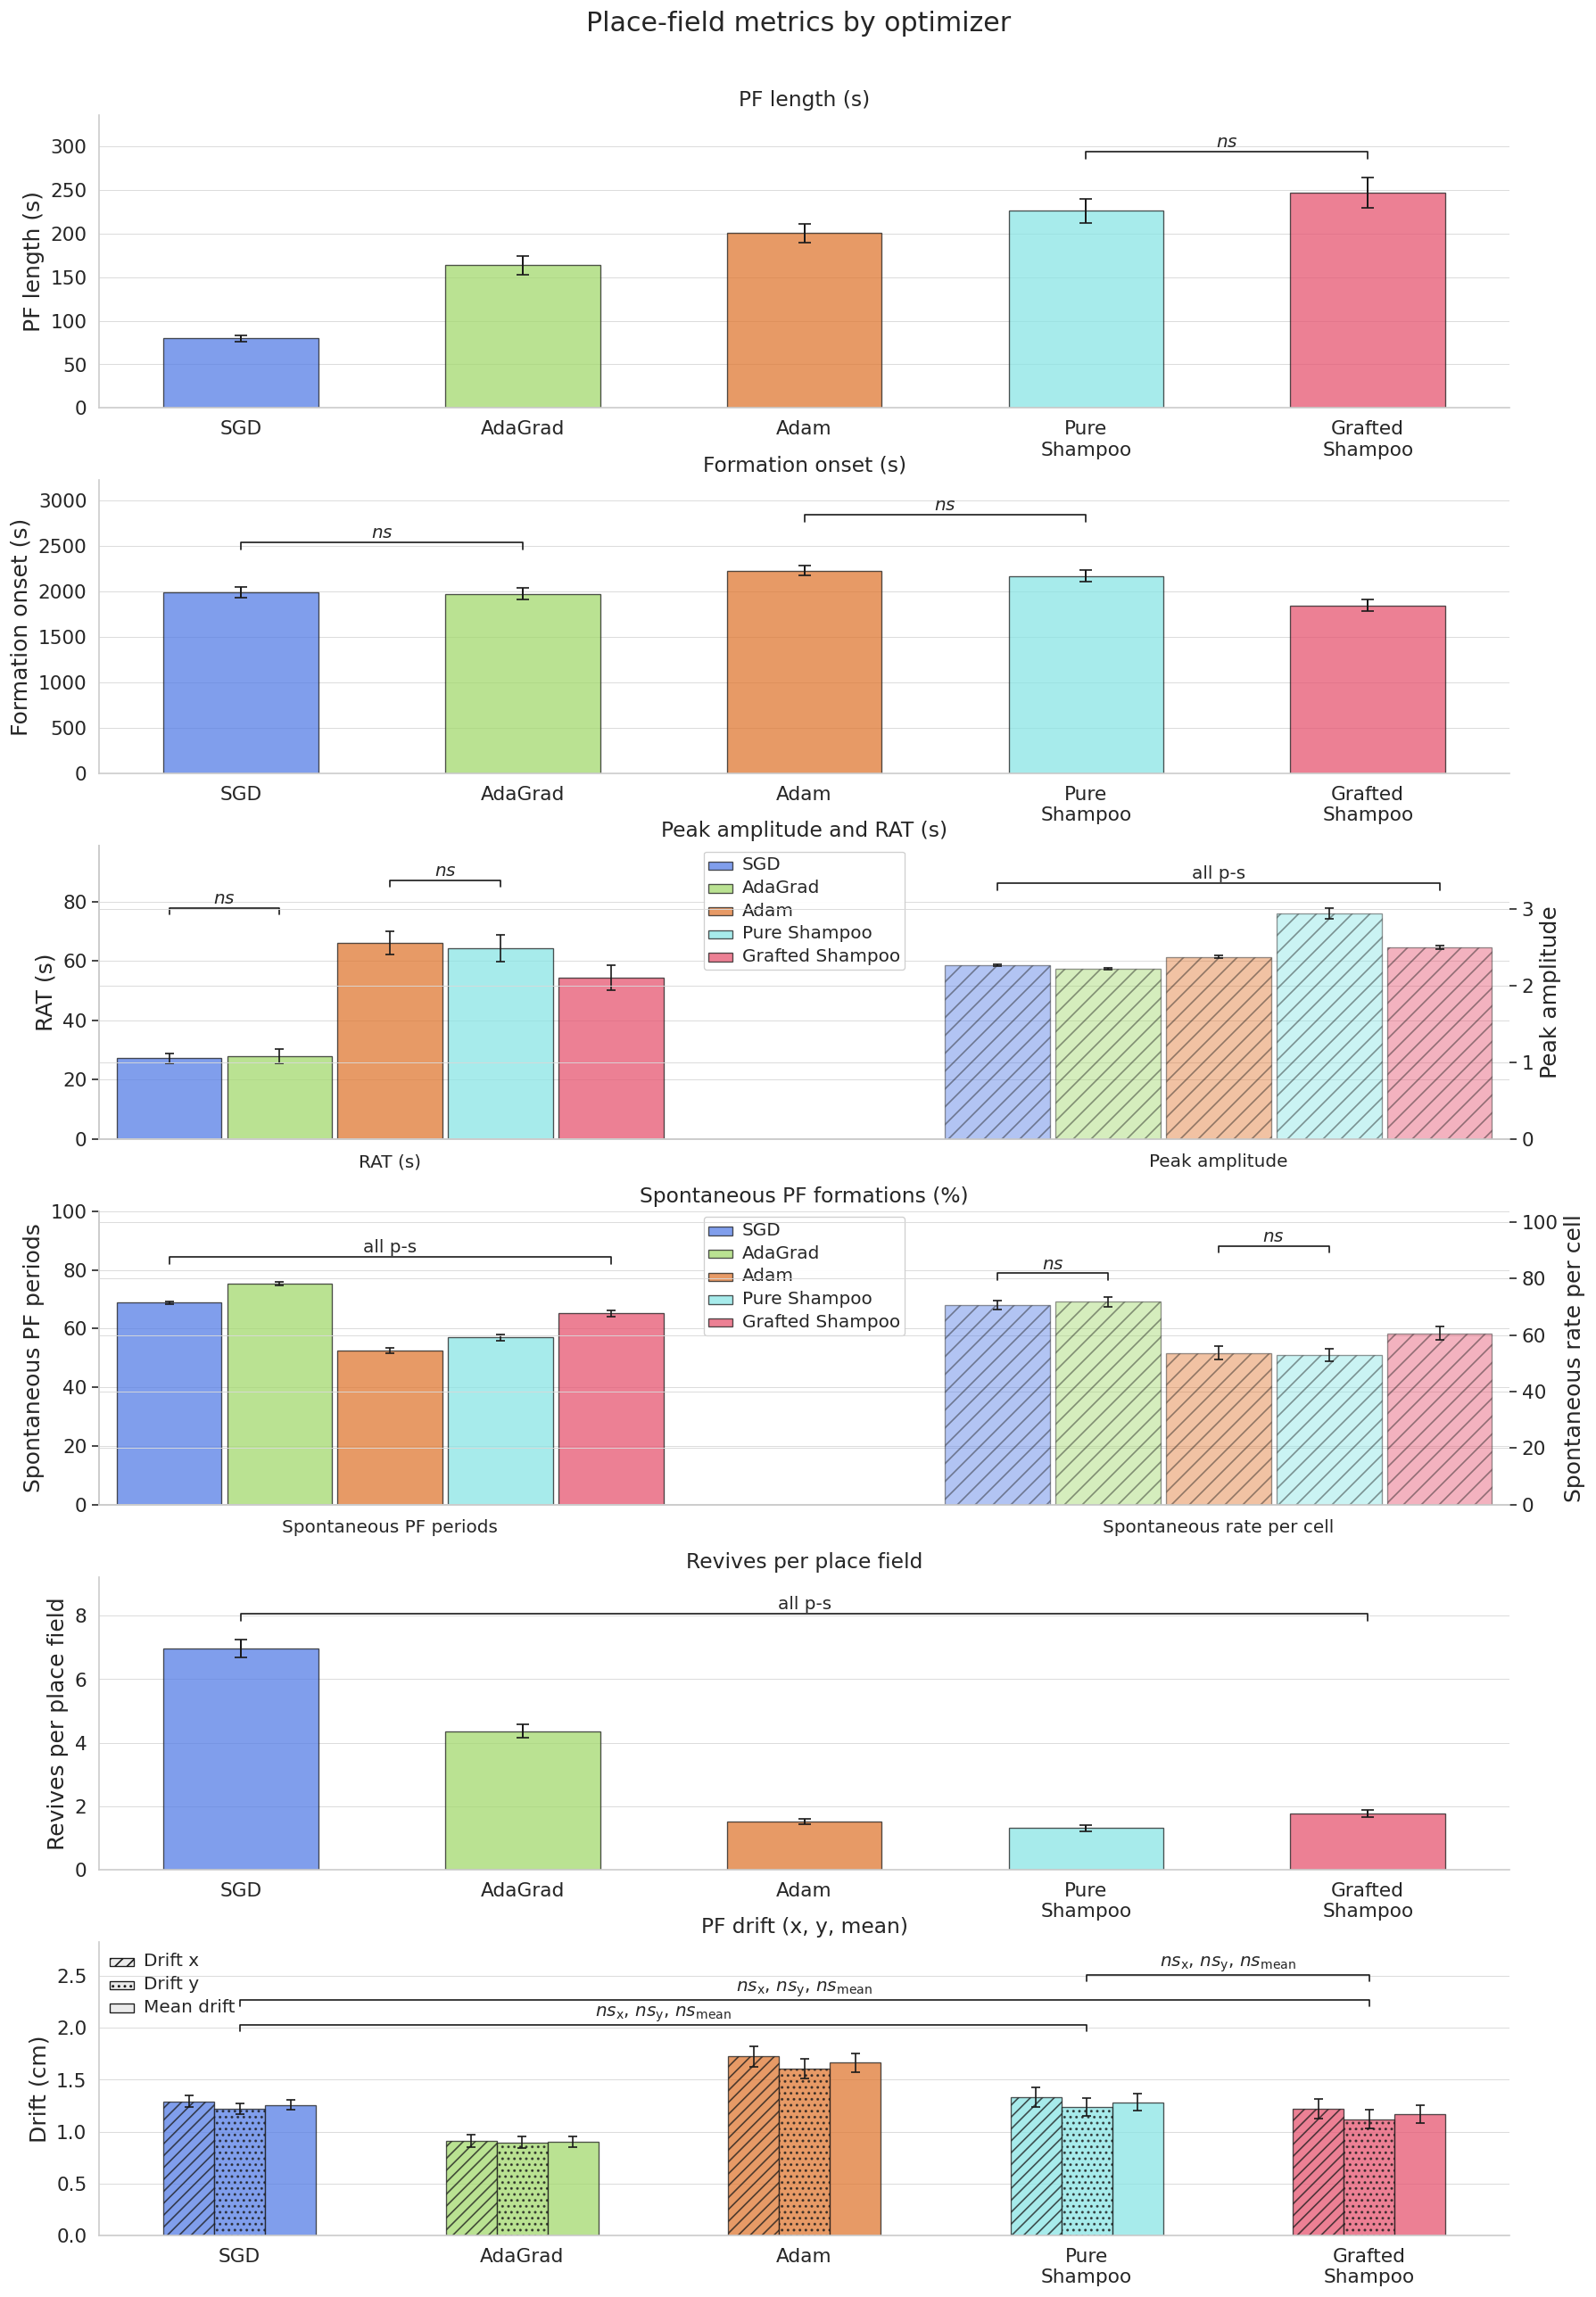

[PF length (s)] 8 significant pair(s) (Welch t-test, Holm corrected):
  SGD vs AdaGrad: raw p=2.70e-16, Holm p=1.61e-15 (***)
  SGD vs Adam: raw p=2.85e-21, Holm p=2.00e-20 (***)
  SGD vs Pure Shampoo: raw p=9.46e-25, Holm p=7.56e-24 (***)
  AdaGrad vs Adam: raw p=7.20e-52, Holm p=6.48e-51 (***)
  AdaGrad vs Pure Shampoo: raw p=9.97e-56, Holm p=9.97e-55 (***)
  AdaGrad vs Grafted Shampoo: raw p=6.16e-15, Holm p=2.46e-14 (***)
  Adam vs Grafted Shampoo: raw p=4.55e-14, Holm p=1.37e-13 (***)
  Pure Shampoo vs Grafted Shampoo: raw p=2.69e-16, Holm p=1.61e-15 (***)
[Formation onset (s)] 8 significant pair(s) (Welch t-test, Holm corrected):
  SGD vs AdaGrad: raw p=6.03e-08, Holm p=3.62e-07 (***)
  SGD vs Adam: raw p=1.08e-03, Holm p=3.29e-03 (**)
  SGD vs Grafted Shampoo: raw p=1.90e-11, Holm p=1.52e-10 (***)
  AdaGrad vs Adam: raw p=1.71e-17, Holm p=1.54e-16 (***)
  AdaGrad vs Pure Shampoo: raw p=1.07e-07, Holm p=5.35e-07 (***)
  Adam vs Pure Shampoo: raw p=8.21e-04, Holm p=3.29e-03 (**)
 

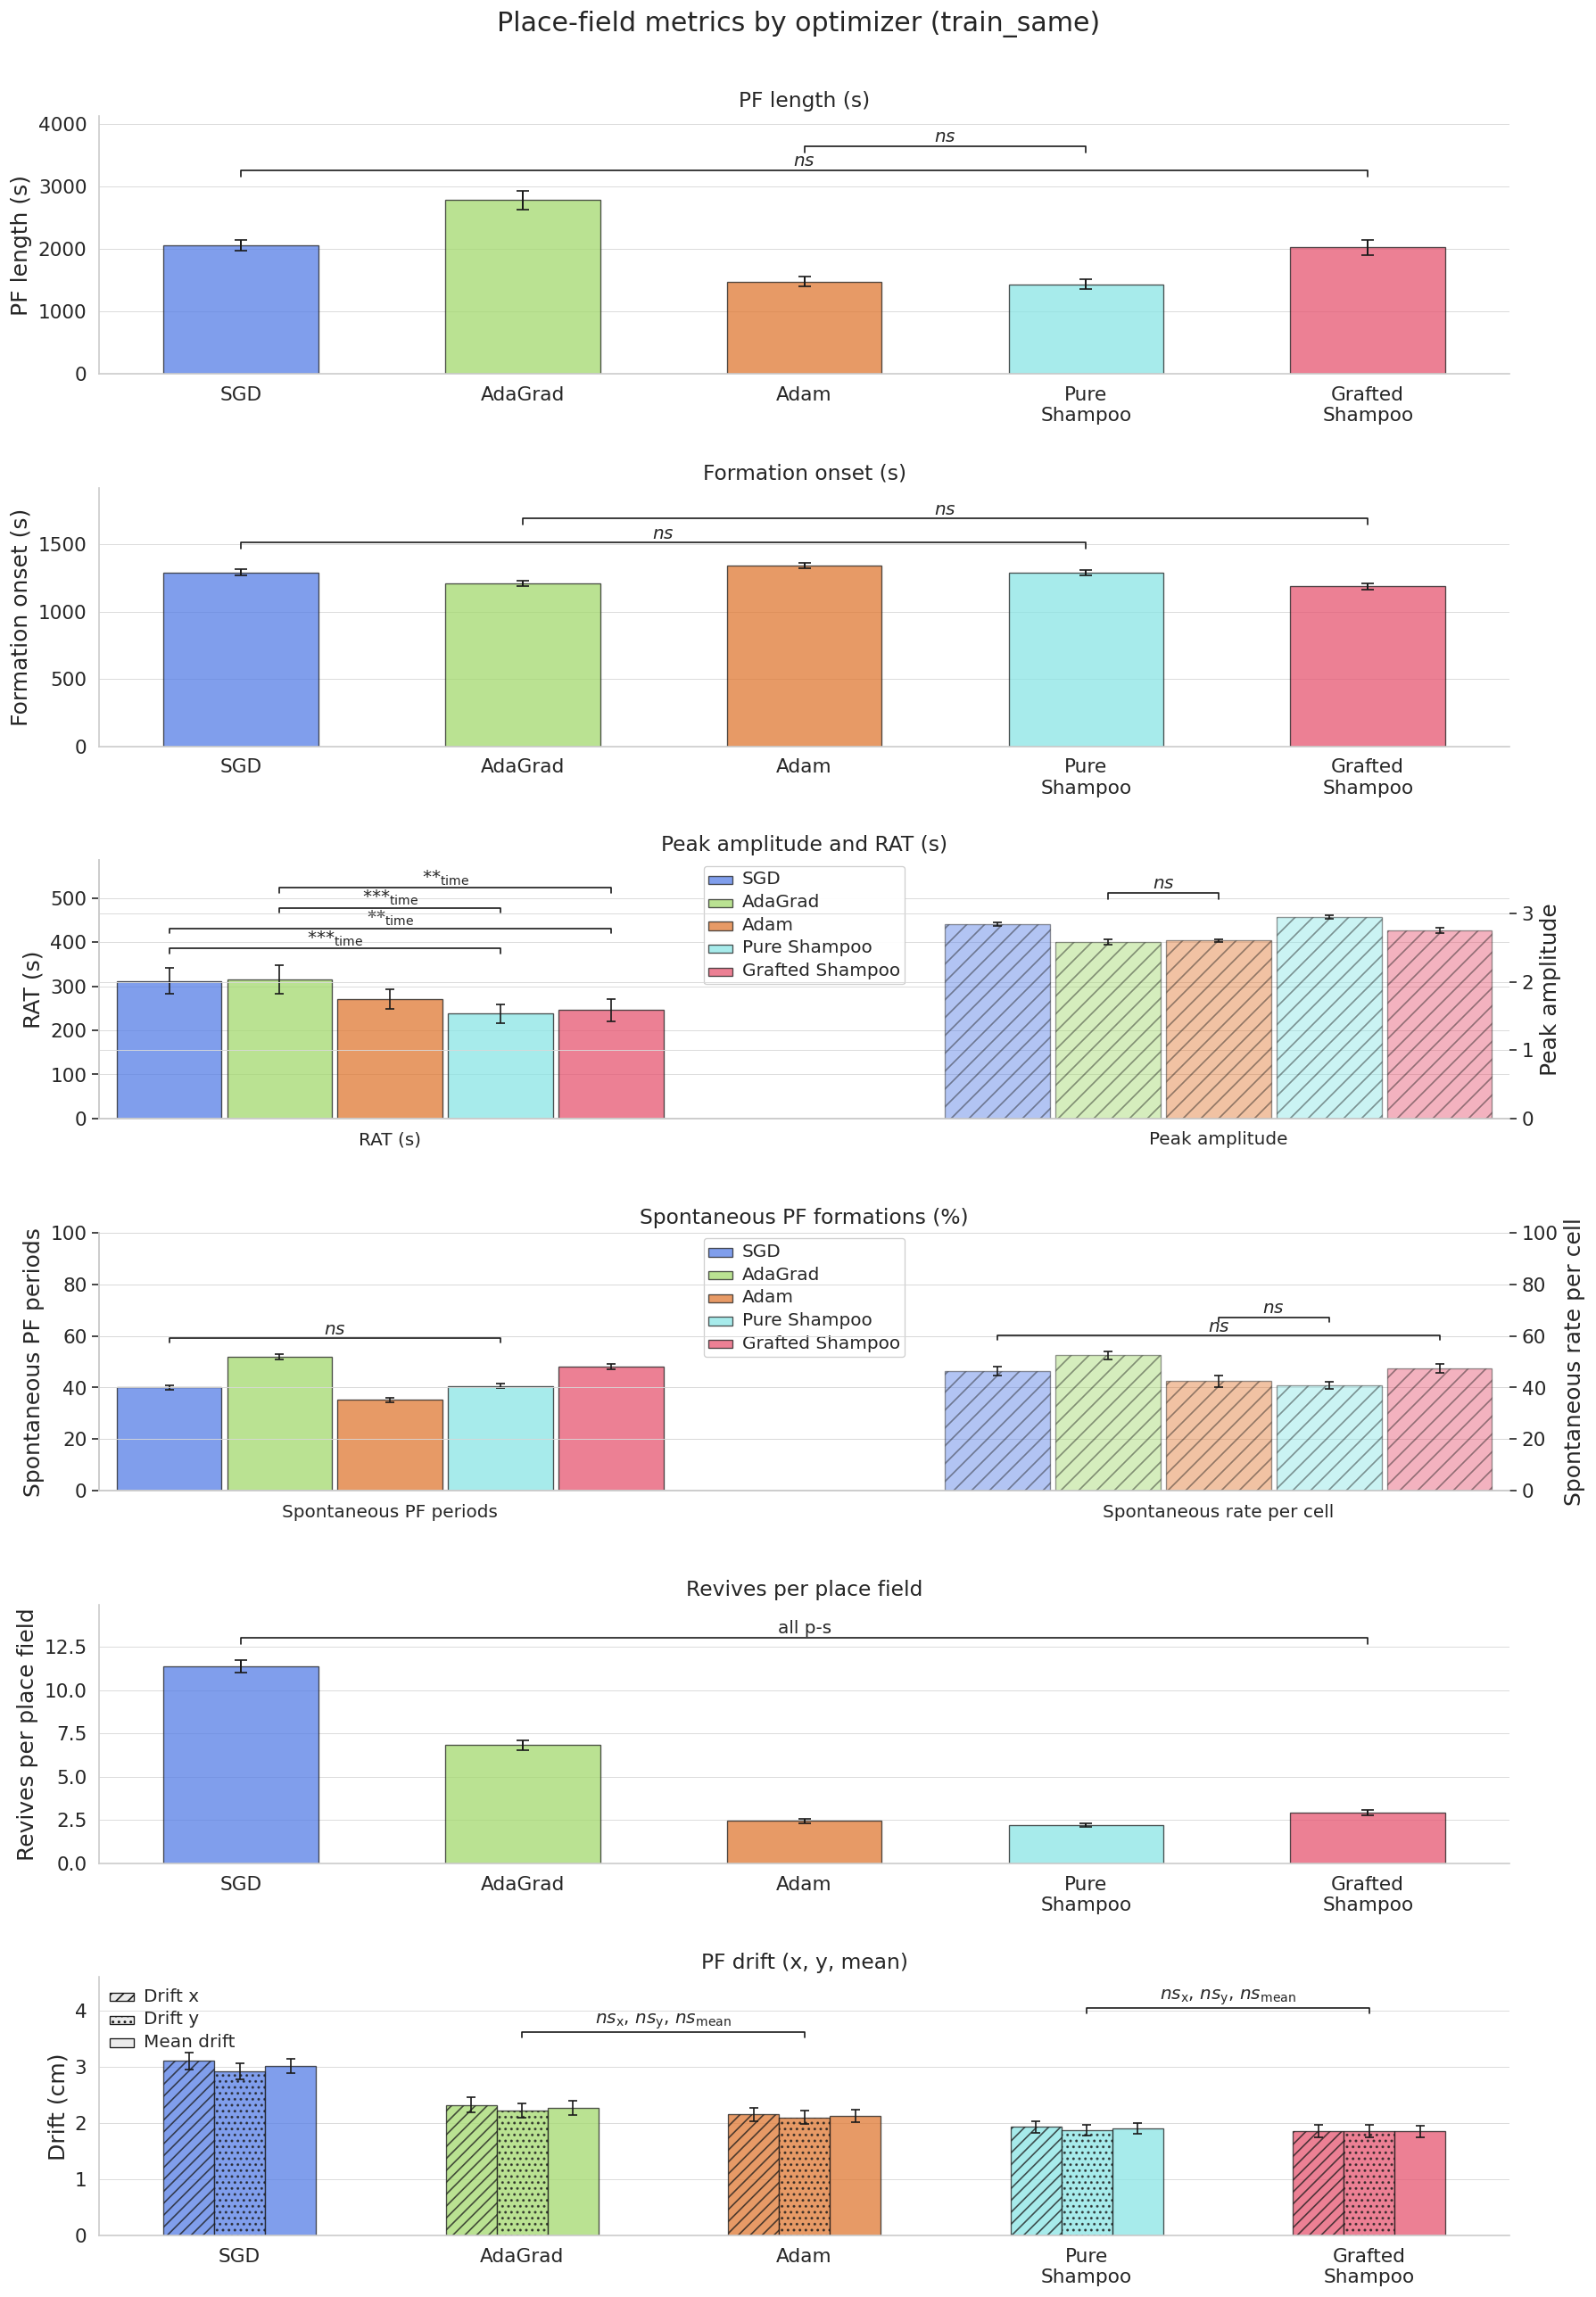

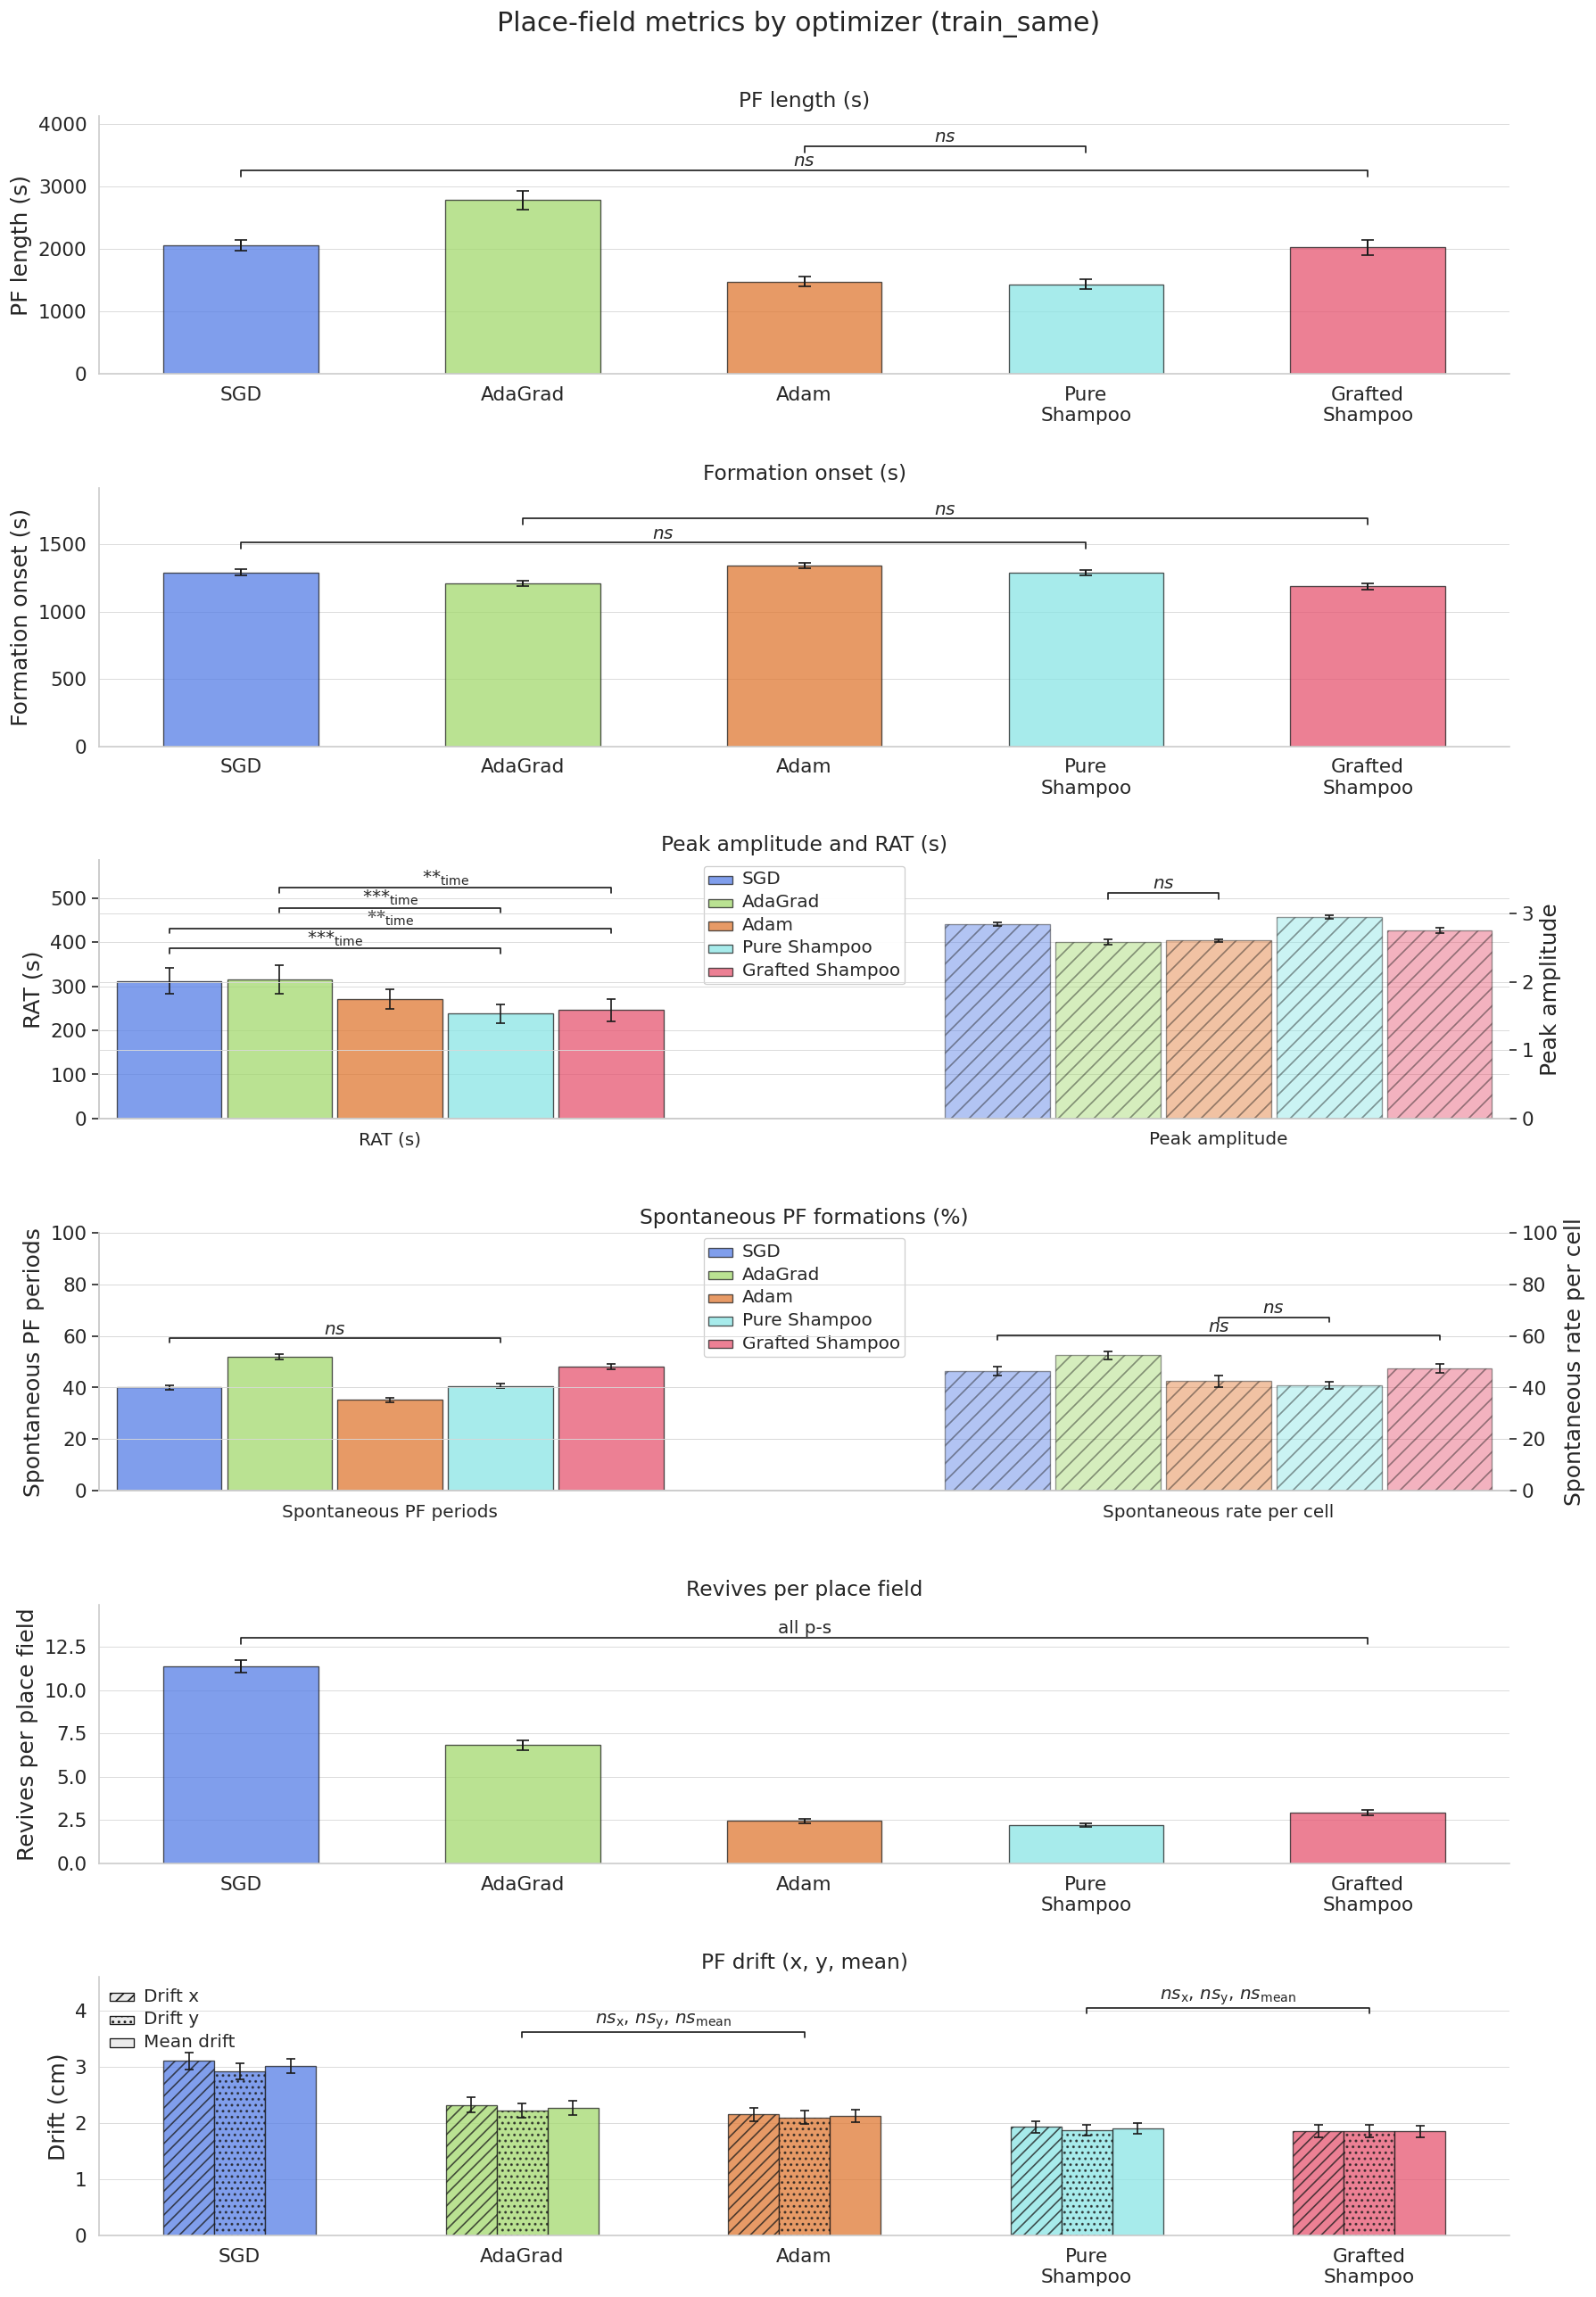

In [42]:
from single_room_multi_opt_plots import plot_pf_metric_bars_by_optimizer
from two_rooms_multi_opt_plots import plot_pf_metric_bars_by_optimizer_two_rooms

fig = plot_pf_metric_bars_by_optimizer(
    sr_results,
    time_unit="seconds",
    show_significance=SHOW_SIGNIFICANCE,
    show_insignificance=SHOW_INSIGNIFICANCE,
)
finalize(fig, PLOT_DIR, "single_room_pf_metric_bars")

fig = plot_pf_metric_bars_by_optimizer_two_rooms(
    tr_pf,
    time_unit="seconds",
    split="aggregated",
    show_significance=SHOW_SIGNIFICANCE,
    show_insignificance=SHOW_INSIGNIFICANCE,
)
finalize(fig, PLOT_DIR, "two_rooms_pf_metric_bars")

## Single room — PF length and drift

Bar charts from `plot_pf_metric_bars_by_optimizer` (PF length and combined PF drift panels), stacked vertically with pairwise significance brackets.

[PF length (s)] 9 significant pair(s) (Welch t-test, Holm corrected):
  SGD vs AdaGrad: raw p=7.40e-46, Holm p=5.18e-45 (***)
  SGD vs Adam: raw p=3.45e-99, Holm p=3.45e-98 (***)
  SGD vs Pure Shampoo: raw p=4.05e-89, Holm p=3.64e-88 (***)
  SGD vs Grafted Shampoo: raw p=3.16e-73, Holm p=2.52e-72 (***)
  AdaGrad vs Adam: raw p=2.00e-06, Holm p=8.02e-06 (***)
  AdaGrad vs Pure Shampoo: raw p=3.64e-12, Holm p=1.82e-11 (***)
  AdaGrad vs Grafted Shampoo: raw p=3.88e-15, Holm p=2.33e-14 (***)
  Adam vs Pure Shampoo: raw p=3.89e-03, Holm p=7.79e-03 (**)
  Adam vs Grafted Shampoo: raw p=9.56e-06, Holm p=2.87e-05 (***)
[PF drift (x, y, mean) / x] 7 significant pair(s):
  SGD vs AdaGrad: raw p=4.86e-21, Holm p=4.37e-20 (***)
  SGD vs Adam: raw p=3.19e-14, Holm p=2.55e-13 (***)
  AdaGrad vs Adam: raw p=2.14e-44, Holm p=2.14e-43 (***)
  AdaGrad vs Pure Shampoo: raw p=1.27e-13, Holm p=8.89e-13 (***)
  AdaGrad vs Grafted Shampoo: raw p=6.16e-08, Holm p=2.46e-07 (***)
  Adam vs Pure Shampoo: raw p=

/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/single_room_multi_opt_plots.py:2489: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/report_final/style.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=rect)


Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_pf_length_and_drift_bars.pdf


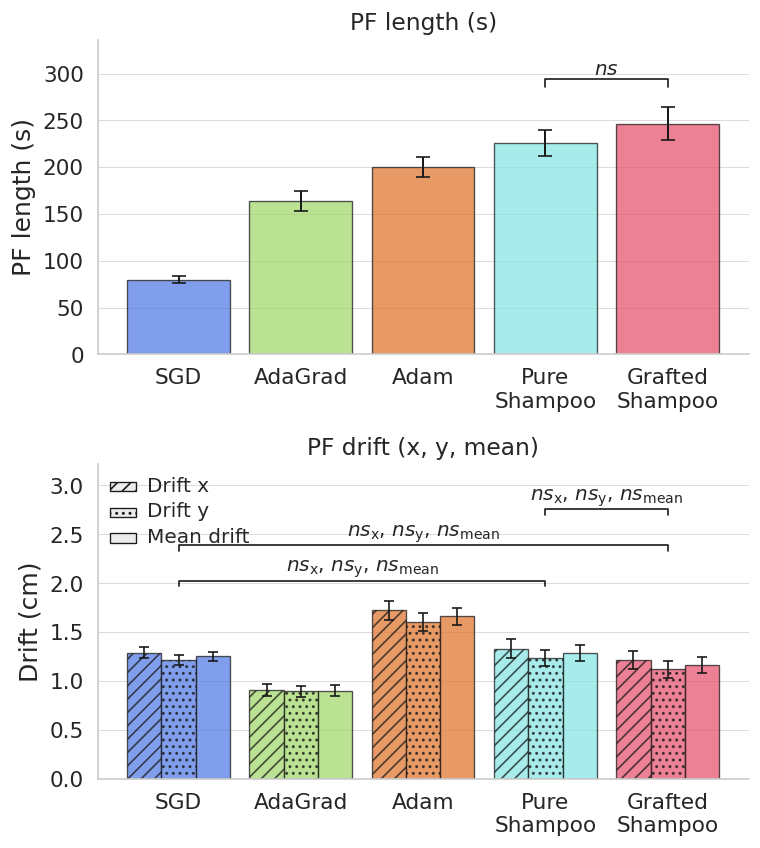

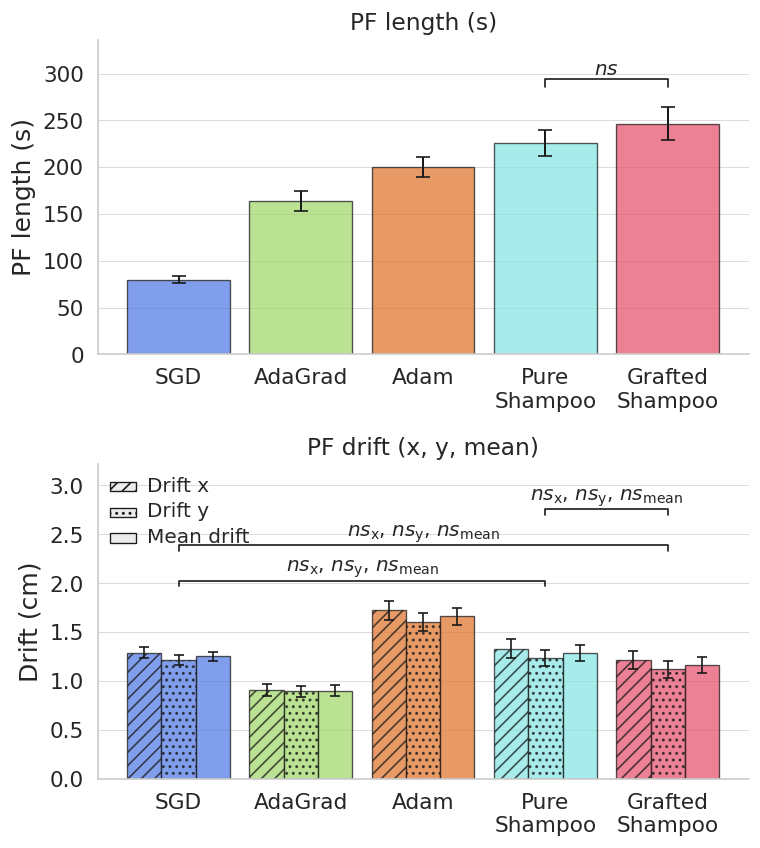

In [43]:
from single_room_multi_opt_compute import pf_metric_bar_panel_specs
from single_room_multi_opt_plots import plot_pf_metric_bars_by_optimizer

PF_LENGTH_DRIFT_TITLE = ""  # set figure suptitle here

_pf_length_drift_specs = [
    spec
    for spec in pf_metric_bar_panel_specs("seconds")
    if (spec[0] == "simple" and spec[1] == "length_s") or spec[0] == "drift"
]

fig = plot_pf_metric_bars_by_optimizer(
    sr_results,
    time_unit="seconds",
    panel_specs=_pf_length_drift_specs,
    title=PF_LENGTH_DRIFT_TITLE,
    figsize=(7.0, 8.0),
    hspace=0.35,
    bar_width=0.84,
    drift_bar_width=0.28,
    drift_bracket_step_mult=2.5,
    show_significance=True,
    show_insignificance=True,
)
finalize(fig, PLOT_DIR, "single_room_pf_length_and_drift_bars")

## Single room — RAT, peak amplitude, and spontaneous PFs

Bar charts from `plot_pf_metric_bars_by_optimizer` (RAT + peak amplitude and
spontaneous PF panels), stacked vertically with pairwise significance brackets.

/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/single_room_multi_opt_plots.py:2489: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/report_final/style.py:231: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=rect)


Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_pf_rat_peak_amp_and_spontaneous_bars.pdf


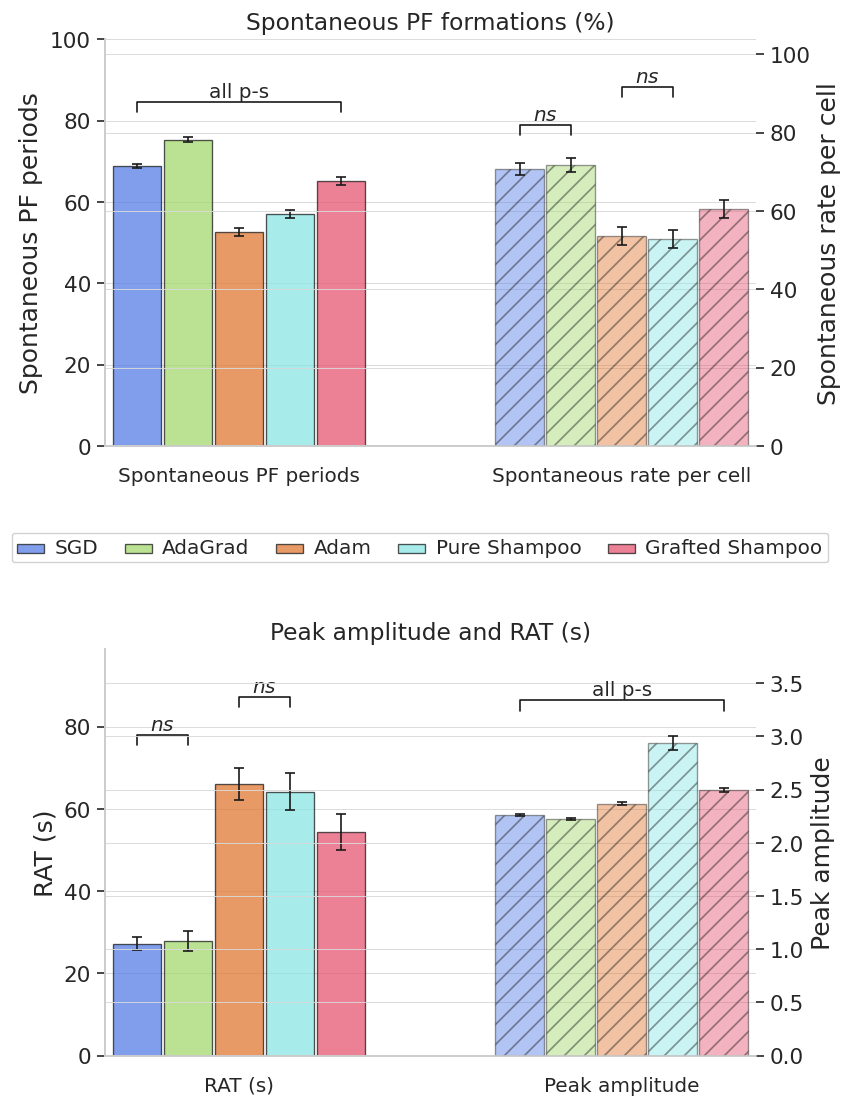

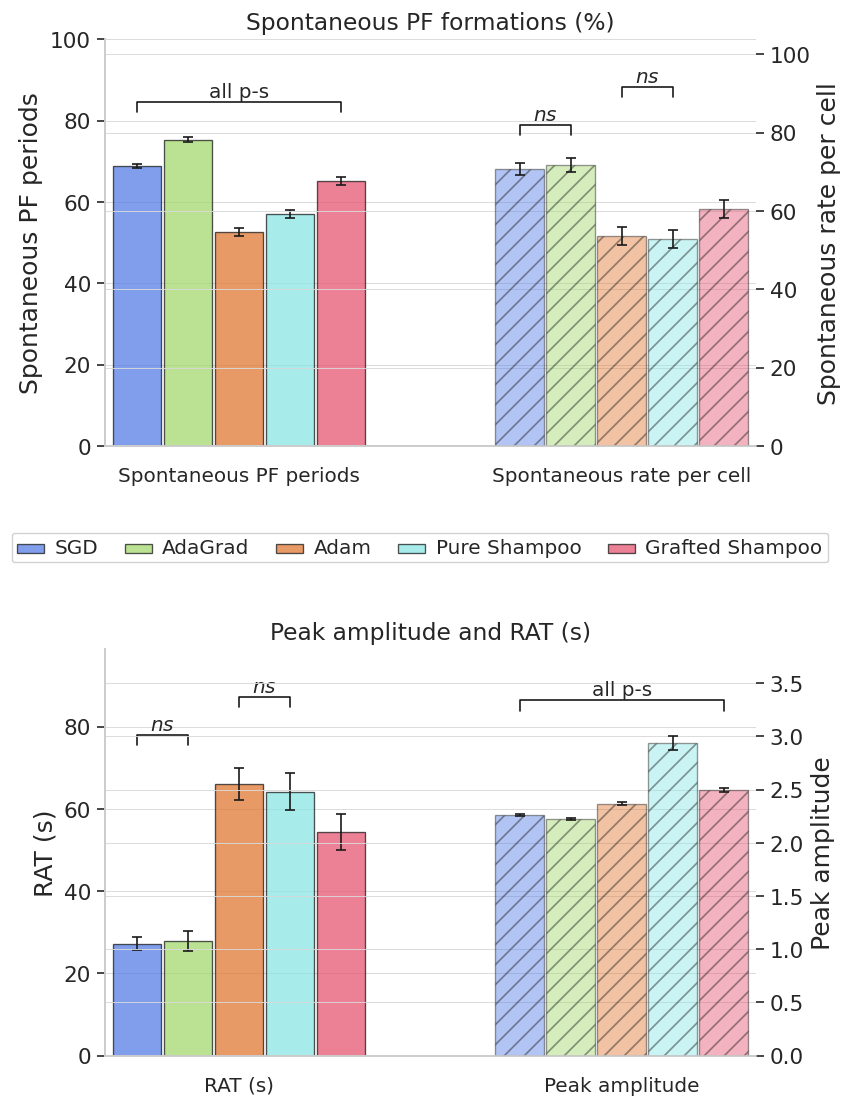

In [44]:
from single_room_multi_opt_plots import plot_pf_metric_bars_by_optimizer

PF_RAT_AMP_SPONTANEOUS_TITLE = ""  # set figure suptitle here

_pf_rat_amp_spontaneous_specs = [
    ("spontaneous", None, None),
    ("amp_tma", None, None),
]

fig = plot_pf_metric_bars_by_optimizer(
    sr_results,
    time_unit="seconds",
    panel_specs=_pf_rat_amp_spontaneous_specs,
    title=PF_RAT_AMP_SPONTANEOUS_TITLE,
    figsize=(7.0, 11.0),
    hspace=0.5,
    show_significance=SHOW_SIGNIFICANCE,
    show_insignificance=SHOW_INSIGNIFICANCE,
    shared_optimizer_legend=True,
    shared_optimizer_legend_ncol=5,
)
finalize(fig, PLOT_DIR, "single_room_pf_rat_peak_amp_and_spontaneous_bars")

## Single room — conditional spontaneity vs field survival

Spontaneous fraction conditioned on place-field lifetime (normal training only).
One-segment fields are trivially spontaneous, so the survival threshold on the
x-axis removes flicker artifacts; x is shown in seconds (10 s per TBPTT segment).

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_conditional_spontaneity_vs_survival.csv
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_conditional_spontaneity_vs_survival.pdf


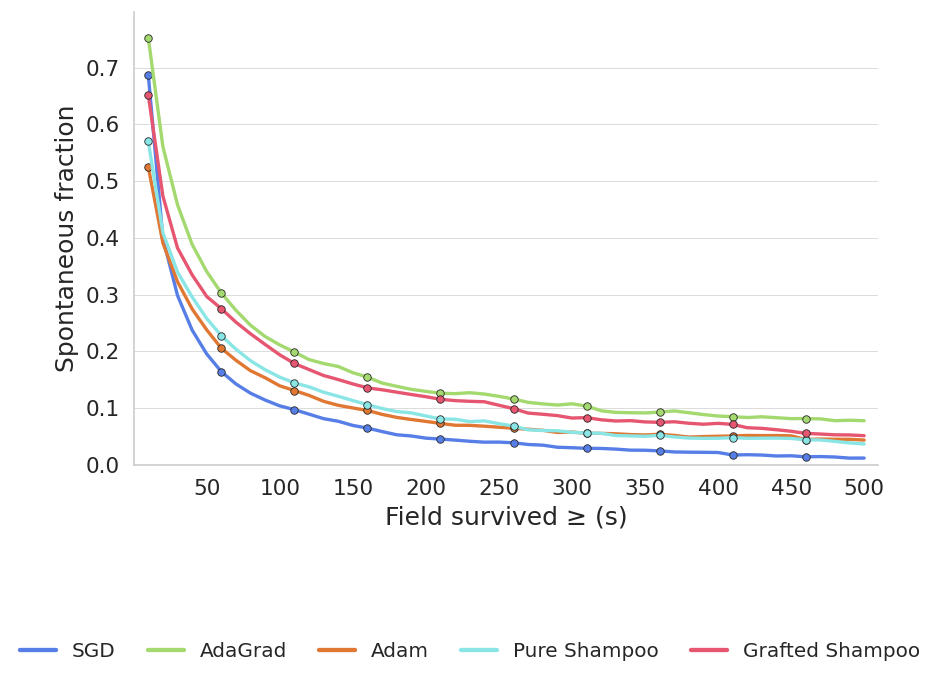

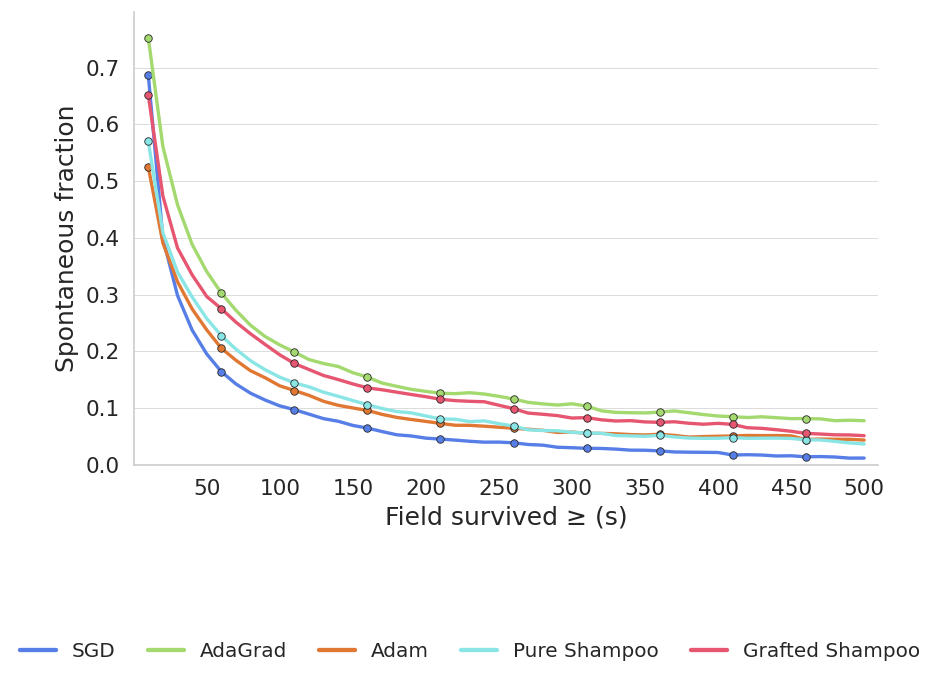

In [45]:
sr_segment_duration_s = next(iter(sr_results.contexts.values())).segment_duration_s

conditional_spont_table = srpf.conditional_spontaneity_table(
    sr_results,
    segment_duration_s=sr_segment_duration_s,
    min_segments=range(1, 51),
    min_periods=30,
)
save_report_table(
    conditional_spont_table,
    PLOT_DIR,
    "single_room_conditional_spontaneity_vs_survival",
)

fig = srpf.plot_conditional_spontaneity_vs_survival(
    conditional_spont_table,
    title="",
    marker_every=5,
)
finalize(fig, PLOT_DIR, "single_room_conditional_spontaneity_vs_survival")

## Single room — final Gaussian peak signal by cell

Per-cell Gaussian `signal_max` at the final capture (`results.meta`): boxplot
distribution plus 99.5th-percentile bars.

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_final_max_signal_by_cell.csv
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_final_max_signal_q995.csv
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_final_max_signal_by_cell.pdf


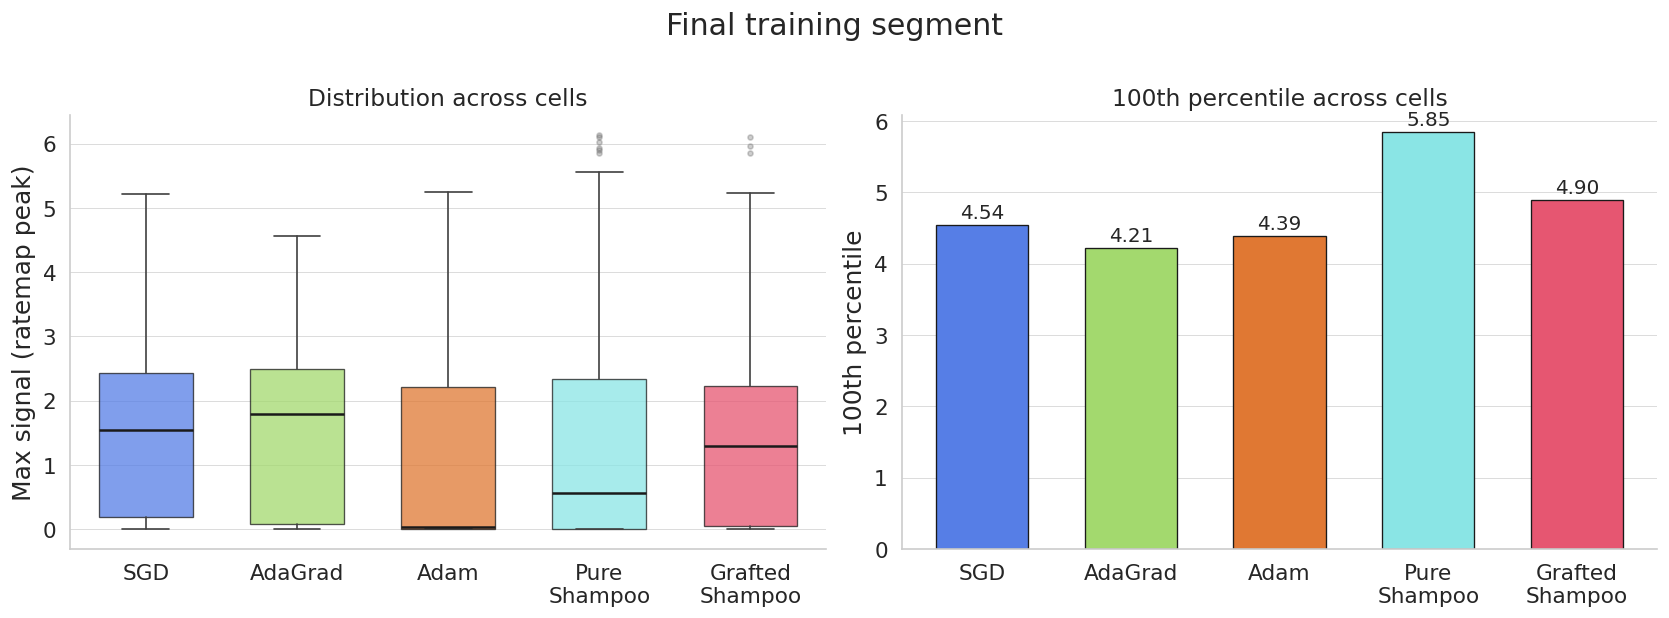

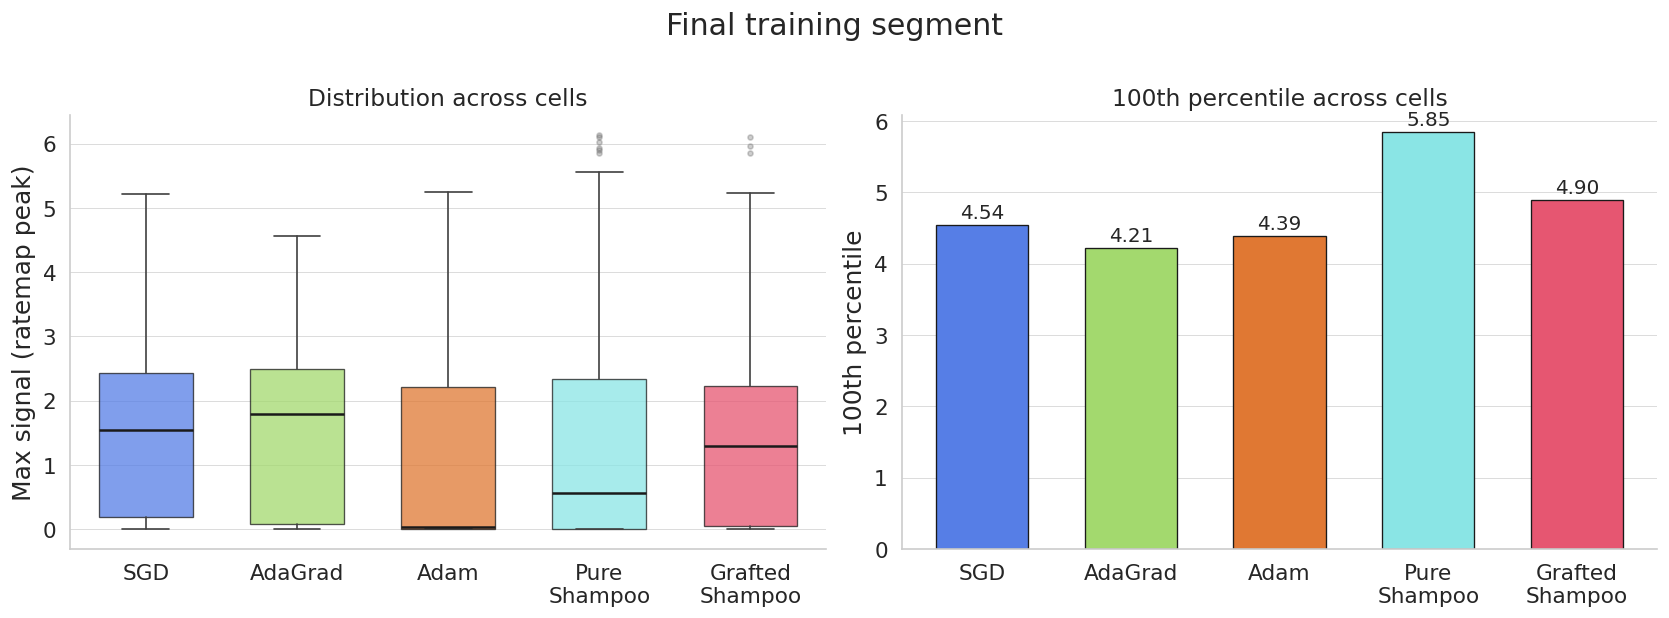

In [46]:
max_signal_table = srmp.max_signal_table_from_results(sr_results)
save_report_table(max_signal_table, PLOT_DIR, "single_room_final_max_signal_by_cell")

max_signal_quantiles = srmp.final_max_signal_quantile_table(max_signal_table, q=0.995)
save_report_table(max_signal_quantiles, PLOT_DIR, "single_room_final_max_signal_q995")

fig = srmp.plot_final_max_signal_boxplot(max_signal_table, quantile=0.995)
finalize(fig, PLOT_DIR, "single_room_final_max_signal_by_cell", restyle=False)

## Single room — revives per PF (normalized)

Same revive counts as `plot_pf_metric_bars_by_optimizer`. Two normalizations:

1. `mean(revives per PF) / n_distinct_place_fields` (network catalog size)
2. `mean_cell(total revives for cell / unique PFs for that cell)`


Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_revives_per_pf_normalized.csv


,optimizer,mean_revives_per_pf,n_distinct_place_fields,mean_revives_per_pf_over_n_distinct,total_revives
0,sgd,6.969290,4168,0.001672,29048
1,adagrad,4.371082,2967,0.001473,12969
2,adam,1.512891,4344,0.000348,6572
3,pure_shampoo,1.313048,3533,0.000372,4639
4,grafted_shampoo,1.778441,2848,0.000624,5065


Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_revives_per_cell_normalized.csv


,optimizer,mean_revives_over_unique_pfs_per_cell,sem_revives_over_unique_pfs_per_cell,n_neurons
0,sgd,4.283525,0.213361,1000
1,adagrad,2.318089,0.109517,1000
2,adam,0.886214,0.056331,1000
3,pure_shampoo,0.642123,0.040111,1000
4,grafted_shampoo,0.818780,0.053350,1000


[Revives per cell (normalized)] 9 significant pair(s) (Welch t-test, Holm corrected):
  SGD vs AdaGrad: raw p=5.33e-16, Holm p=2.13e-15 (***)
  SGD vs Adam: raw p=1.01e-48, Holm p=8.06e-48 (***)
  SGD vs Pure Shampoo: raw p=3.10e-56, Holm p=3.10e-55 (***)
  SGD vs Grafted Shampoo: raw p=1.13e-50, Holm p=1.02e-49 (***)
  AdaGrad vs Adam: raw p=5.65e-30, Holm p=2.83e-29 (***)
  AdaGrad vs Pure Shampoo: raw p=1.77e-43, Holm p=1.24e-42 (***)
  AdaGrad vs Grafted Shampoo: raw p=3.53e-33, Holm p=2.12e-32 (***)
  Adam vs Pure Shampoo: raw p=4.26e-04, Holm p=1.28e-03 (**)
  Pure Shampoo vs Grafted Shampoo: raw p=8.20e-03, Holm p=1.64e-02 (*)
Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_revives_per_cell_normalized.pdf


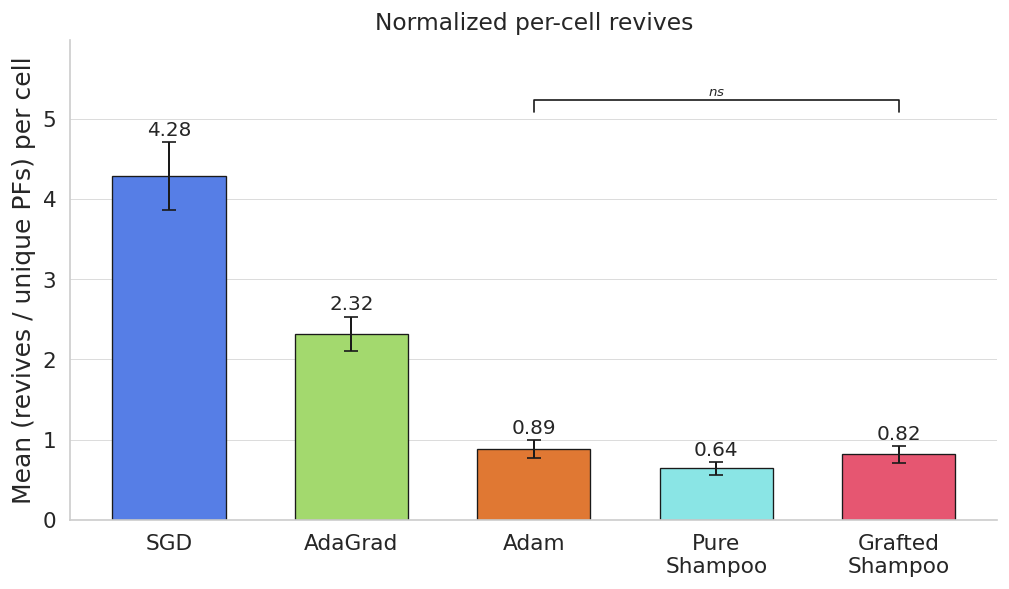

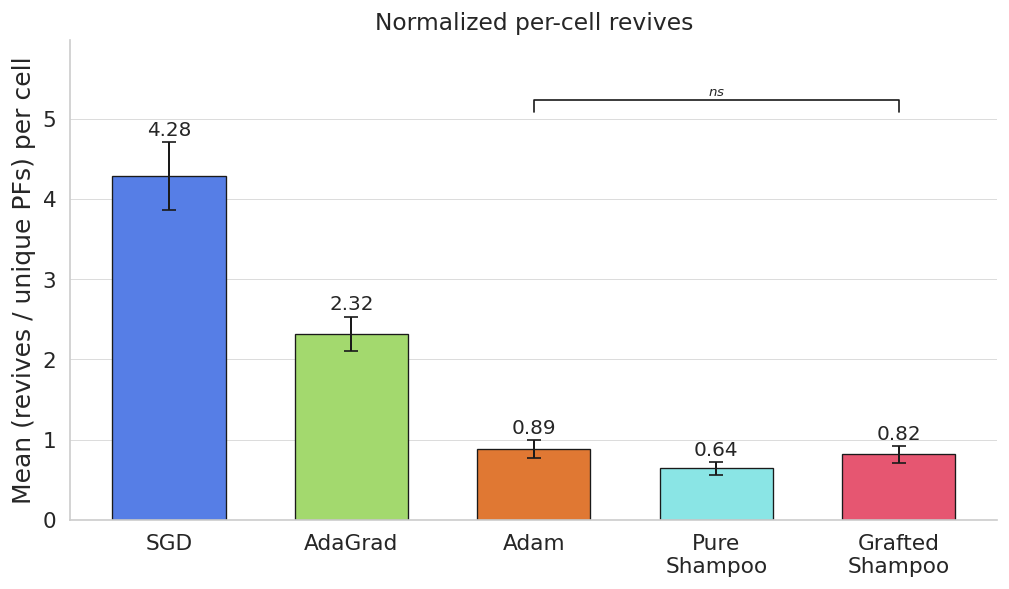

In [47]:
revives_table = srpf.revives_per_pf_normalized_table(sr_results)
save_report_table(revives_table, PLOT_DIR, "single_room_revives_per_pf_normalized")
display(revives_table)

# fig = srpf.plot_revives_per_pf_normalized_by_optimizer(revives_table)
# finalize(fig, PLOT_DIR, "single_room_revives_per_pf_normalized", restyle=False)

revives_cell_table = srpf.revives_per_cell_normalized_table(sr_results)
save_report_table(revives_cell_table, PLOT_DIR, "single_room_revives_per_cell_normalized")
display(revives_cell_table)

fig = srpf.plot_revives_per_cell_normalized_by_optimizer(
    revives_cell_table,
    values_by_optimizer=srpf.per_cell_revives_normalized_values_by_optimizer(sr_results),
    show_significance=SHOW_SIGNIFICANCE,
    show_insignificance=SHOW_INSIGNIFICANCE,
)
finalize(fig, PLOT_DIR, "single_room_revives_per_cell_normalized", restyle=False)


## Single room — final Gaussian fits by activity rank

Last training capture; rendered Gaussian RF fits. Cells sorted by Gaussian
`signal_max` (descending). Row 0 = most active, row 1 = 7th most active.
One column per optimizer, shared colormap.

Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_final_gaussian_activity_ranks.csv


,optimizer,activity_rank,cell_idx,max_signal
0,sgd,0,973,5.218750
1,sgd,7,829,4.476562
2,adagrad,0,719,4.562500
3,adagrad,7,791,4.125000
4,adam,0,39,5.253906
5,adam,7,481,4.273438
6,pure_shampoo,0,501,6.140625
7,pure_shampoo,7,407,5.488281
8,grafted_shampoo,0,701,6.109375
9,grafted_shampoo,7,473,4.664062


Saved /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/local/plots/final/aide/single_room_final_gaussian_activity_ranks.pdf


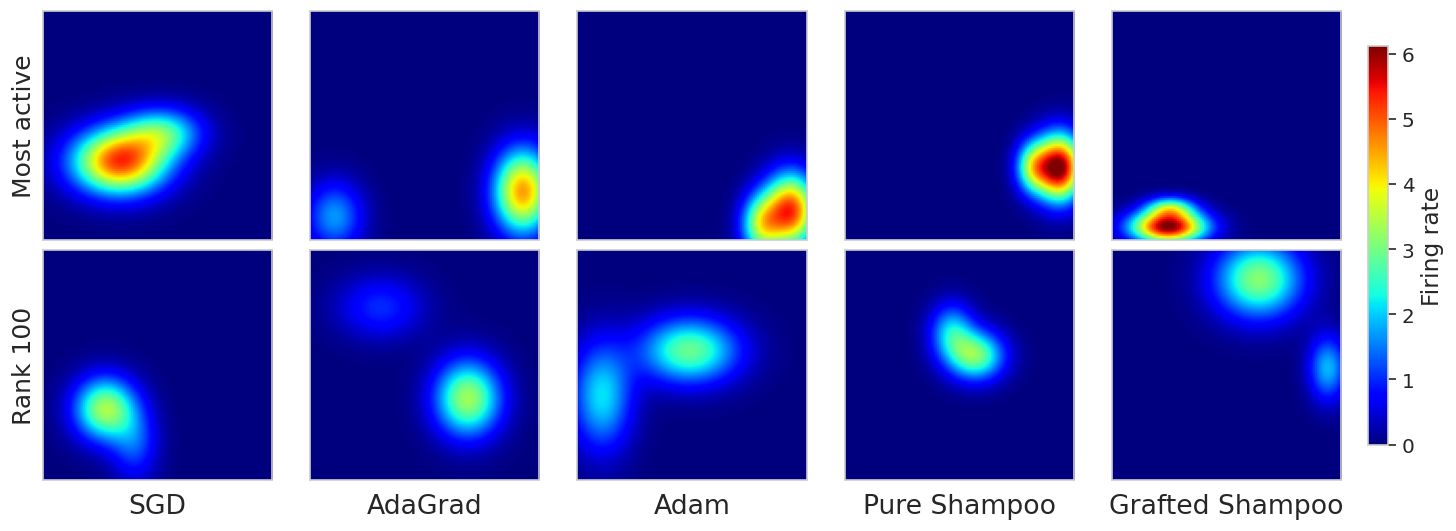

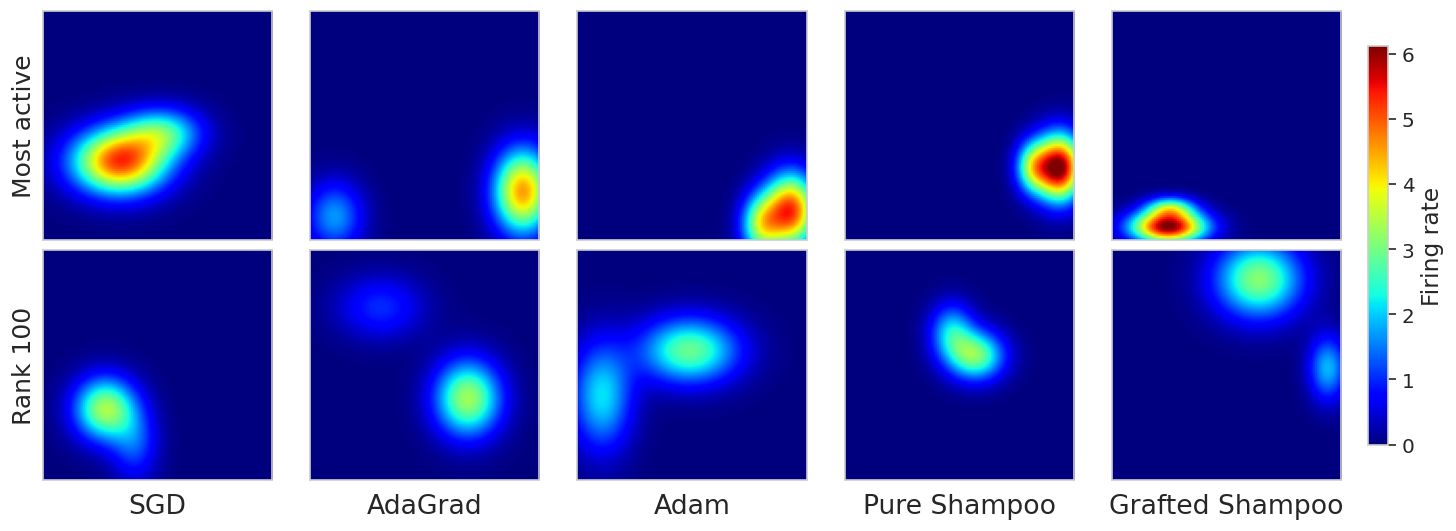

In [48]:
final_gaussian_ratemaps, final_gaussian_peaks = srmp.final_fields_from_results(sr_results)

activity_rank_table = srmp.activity_rank_cell_table(
    final_gaussian_ratemaps,
    ranks=(0, 7),
    peak_rates=final_gaussian_peaks,
)
save_report_table(activity_rank_table, PLOT_DIR, "single_room_final_gaussian_activity_ranks")
display(activity_rank_table)

fig = srmp.plot_final_ratemap_activity_ranks(
    final_gaussian_ratemaps,
    ranks=(0, 100),
    peak_rates=final_gaussian_peaks,
    vmax=sr_results.shared_ratemap_vmax,
    field_label="Gaussian fit",
	title = ""
)
finalize(
    fig,
    PLOT_DIR,
    "single_room_final_gaussian_activity_ranks",
    restyle=False,
    tighten=False,
)
